# Кто не получит зачёт — решение

**Задача.** По анкете и учебному поведению студента предсказать, кто не получит зачёт
(`G3 < 10`), и назвать **три фактора**, которые влияют сильнее всего.

**Два уровня.**

| Уровень | Признаки | Когда работает | Ориентир ТЗ |
|---|---|---|---|
| 1 — базовый | все, включая `G1`, `G2` | конец семестра | ROC-AUC ≈ 0.97 |
| 2 — сложный | **без `G1`, `G2`** | до первой контрольной | ROC-AUC ≈ 0.83 |

Уровень 2 — главный: именно он оставляет куратору время что-то сделать.

**Как читать метрики.** Везде `среднее ± стандартное отклонение` по
**повторяющейся** стратифицированной кросс-валидации (`RepeatedStratifiedKFold`, 5 фолдов × 5 повторов
= 25 оценок). Одиночный train/test-сплит на 649 строках даёт разброс ±0.05 и ничего не доказывает.

**Две метрики.** ROC-AUC — насколько хорошо модель *ранжирует* студентов.
PR-AUC — насколько чист будет список, который получит куратор. При 15 % незачётов
PR-AUC информативнее: у случайной модели он равен доле положительного класса (0.154), а не 0.5.

## 0. Загрузка, версии, фиксация случайности

In [1]:
import sys, os, time, json, warnings, platform
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import sklearn

t_start = time.time()
SEED = 42
np.random.seed(SEED)

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 200)
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True,
                     "grid.alpha": .25, "axes.axisbelow": True})

print("Python     ", sys.version.split()[0], "|", platform.system())
for m in (np, pd, sklearn, matplotlib):
    print(f"{m.__name__:12s}", m.__version__)

Python      3.11.9 | Windows
numpy        2.2.6
pandas       2.3.3
sklearn      1.9.0
matplotlib   3.11.1


Опциональные библиотеки подключаются через `try/except`. Если их нет — ноутбук
не падает, а честно откатывается на `HistGradientBoostingClassifier` из sklearn
и на permutation importance вместо SHAP. Ниже печатается, что реально доступно.

In [2]:
HAS = {}
try:
    from lightgbm import LGBMClassifier; HAS["lightgbm"] = True
except Exception: HAS["lightgbm"] = False
try:
    from xgboost import XGBClassifier;  HAS["xgboost"] = True
except Exception: HAS["xgboost"] = False
try:
    from catboost import CatBoostClassifier; HAS["catboost"] = True
except Exception: HAS["catboost"] = False
try:
    import shap; HAS["shap"] = True
except Exception: HAS["shap"] = False
try:
    from imblearn.over_sampling import SMOTE
    from imblearn.pipeline import Pipeline as ImbPipeline
    HAS["imblearn"] = True
except Exception: HAS["imblearn"] = False

print("доступные опциональные библиотеки:")
for k, v in HAS.items():
    print(f"  {k:10s} {'есть' if v else 'НЕТ — используется фолбэк'}")

# Тяжёлый перебор гиперпараметров выключен: его результат вписан в BEST_PARAMS ниже.
# Поставьте True, чтобы воспроизвести поиск (это занимает ~20 минут).
RUN_HEAVY_SEARCH = False

доступные опциональные библиотеки:
  lightgbm   есть
  xgboost    есть
  catboost   есть
  shap       есть
  imblearn   есть


In [3]:
from sklearn.base import clone
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler
from sklearn.model_selection import (RepeatedStratifiedKFold, StratifiedKFold, cross_validate,
                                     cross_val_predict, train_test_split, RandomizedSearchCV)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier,
                              HistGradientBoostingClassifier, GradientBoostingClassifier,
                              VotingClassifier, StackingClassifier)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.dummy import DummyClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.inspection import permutation_importance
from sklearn.metrics import (roc_auc_score, average_precision_score, confusion_matrix,
                             classification_report, precision_recall_curve, roc_curve,
                             brier_score_loss)

df_por = pd.read_csv("student-por.csv", sep=";")   # ВАЖНО: разделитель ';'
df_mat = pd.read_csv("student-mat.csv", sep=";")
print("португальский:", df_por.shape, " математика:", df_mat.shape)
df_por.head(3)

португальский: (649, 33)  математика: (395, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,0,yes,no,no,no,yes,yes,yes,no,4,3,2,2,3,3,6,12,13,12


## 1. Целевая переменная и разбор `G3 == 0`

Готовой колонки «зачёт / незачёт» в файле нет. Порог зачёта в португальской системе — 10 из 20.

In [4]:
for d in (df_por, df_mat):
    d["no_pass"] = (d["G3"] < 10).astype(int)

print("ПОРТУГАЛЬСКИЙ")
print(df_por["no_pass"].value_counts().rename({0: "зачёт", 1: "незачёт"}).to_string())
print("доля незачётов:", round(df_por["no_pass"].mean(), 4))
print("\nМАТЕМАТИКА")
print(df_mat["no_pass"].value_counts().rename({0: "зачёт", 1: "незачёт"}).to_string())
print("доля незачётов:", round(df_mat["no_pass"].mean(), 4))

ПОРТУГАЛЬСКИЙ
no_pass
зачёт      549
незачёт    100
доля незачётов: 0.1541

МАТЕМАТИКА
no_pass
зачёт      265
незачёт    130
доля незачётов: 0.3291


### 1.1 Пятнадцать студентов с `G3 == 0`

`G3 == 0` — это почти наверняка не «написал работу на ноль», а «человек не дошёл до итога».
Вопрос, который надо решить явно: «бросил» и «не сдал» — одно событие или разные?
Смотрим на их оценки за контрольные и на пропуски.

In [5]:
z = df_por[df_por.G3 == 0]
print(f"студентов с G3 == 0: {len(z)}\n")
print(z[["G1", "G2", "G3", "absences", "studytime", "failures", "higher", "schoolsup"]].to_string())

print("\nиз них имели проходной балл на 2-й контрольной (G2 >= 10):", int((z.G2 >= 10).sum()))
print("имели G2 == 0 (то есть пропали уже ко 2-й контрольной):", int((z.G2 == 0).sum()))
print("имели G1 == 0:", int((z.G1 == 0).sum()))

студентов с G3 == 0: 15

     G1  G2  G3  absences  studytime  failures higher schoolsup
163  11   9   0         0          1         2     no        no
440   7   0   0         0          2         0    yes        no
519   8   7   0         0          2         0    yes        no
563   7   0   0         0          1         1    yes        no
567   4   0   0         0          1         1     no        no
583   8   6   0         0          1         1     no        no
586   8   8   0         0          2         0    yes       yes
597   9   0   0         0          2         1    yes        no
603   5   0   0         0          2         0    yes        no
605   5   0   0         0          1         1     no        no
610   8   0   0         0          2         3     no        no
626   7   5   0         0          2         0    yes        no
637   7   7   0         0          1         0    yes        no
639   5   8   0         0          1         1    yes        no
640   7   7   0

In [6]:
cols = ["G1", "G2", "absences", "failures", "studytime", "goout"]
grp = pd.DataFrame({
    f"G3==0 (n={len(z)})": z[cols].mean(),
    f"незачёт, G3>0 (n={int(((df_por.no_pass==1)&(df_por.G3>0)).sum())})":
        df_por[(df_por.no_pass == 1) & (df_por.G3 > 0)][cols].mean(),
    f"зачёт (n={int((df_por.no_pass==0).sum())})":
        df_por[df_por.no_pass == 0][cols].mean(),
}).round(2)
print(grp.to_string())

           G3==0 (n=15)  незачёт, G3>0 (n=85)  зачёт (n=549)
G1                 7.07                  7.91          12.06
G2                 3.80                  8.19          12.31
absences           0.00                  5.42           3.49
failures           0.80                  0.74           0.13
studytime          1.47                  1.64           1.99
goout              3.07                  3.42           3.15


**Вывод по `G3 == 0`.** Решение принимаем не «на глаз», а по данным: в разделе 5.4 считаем
все метрики в двух вариантах (с этими 15 студентами и без них) и смотрим, меняется ли от
этого тройка главных факторов. Забегая вперёд — **оставляем**. Обоснование содержательное:
заказчику нужен список тех, «с кем стоит поговорить», а студент, который перестал ходить
и не дошёл до итога, — ровно тот случай, ради которого система и строится. Выкинуть его
значило бы учить модель не замечать самый тяжёлый исход.

## 2. Смотрим на данные

In [7]:
RU = {
    'absences': 'пропуски занятий', 'studytime': 'часы самоподготовки', 'failures': 'прошлые незачёты',
    'G1': 'контрольная 1', 'G2': 'контрольная 2', 'G3': 'итоговый балл',
    'traveltime': 'дорога до школы', 'famrel': 'отношения в семье', 'freetime': 'свободное время',
    'goout': 'встречи с друзьями', 'Dalc': 'алкоголь в будни', 'Walc': 'алкоголь в выходные',
    'health': 'здоровье', 'age': 'возраст', 'Medu': 'образование матери', 'Fedu': 'образование отца',
    'schoolsup': 'доп. поддержка школы', 'famsup': 'поддержка семьи', 'paid': 'платные занятия',
    'higher': 'хочет учиться дальше', 'internet': 'интернет дома', 'romantic': 'отношения',
    'activities': 'кружки', 'nursery': 'ходил в садик', 'school': 'учебное заведение',
    'sex': 'пол', 'address': 'город/село', 'famsize': 'размер семьи', 'Pstatus': 'родители вместе',
    'Mjob': 'работа матери', 'Fjob': 'работа отца', 'reason': 'причина выбора', 'guardian': 'опекун',
    # инженерные признаки (раздел 4)
    'alc_total': 'алкоголь всего', 'n_support': 'видов поддержки', 'any_support': 'есть поддержка',
    'abs_per_study': 'пропусков на час самоподготовки', 'log_absences': 'log(пропуски)',
    'abs_zero': 'ни одного пропуска', 'fail_x_study': 'незачёты x самоподготовка',
    'has_failures': 'были незачёты', 'parent_edu_max': 'образование родителей (макс.)',
    'parent_edu_mean': 'образование родителей (сред.)', 'age_over_17': 'старше 17',
    'goout_x_alc': 'друзья x алкоголь', 'study_minus_free': 'учёба минус свободное время',
    'no_higher': 'НЕ хочет учиться дальше', 'risk_count': 'счётчик риск-факторов',
    'abs_bin': 'пропуски (бины)', 'age_bin': 'возраст (бины)',
    'alc_weekday_share': 'доля будних в алкоголе',
    'G_diff': 'динамика G2-G1', 'G_mean': 'средняя за контрольные', 'G_min': 'худшая контрольная',
    'G_proj': 'линейный прогноз на G3', 'G1_fail': 'провалил 1-ю', 'G2_fail': 'провалил 2-ю',
    'G_both_fail': 'провалил обе', 'G_declining': 'оценка падает', 'G1_margin': 'G1 - 10',
    'school_GP': 'школа GP', 'sex_F': 'пол Ж', 'address_U': 'город', 'famsize_GT3': 'семья >3',
    'Pstatus_T': 'родители вместе',
}
def ru(c):
    return RU.get(c, c)

print("пропусков в данных:", int(df_por.isna().sum().sum()))
print("дубликатов строк:", int(df_por.duplicated().sum()))
print("\nсколько колонок каждого типа:")
print(df_por.dtypes.value_counts().to_string())

пропусков в данных: 0
дубликатов строк: 0

сколько колонок каждого типа:
object    17
int64     17


In [8]:
key = ['absences', 'studytime', 'failures', 'G1', 'G2', 'goout', 'Dalc', 'age']
t = df_por.groupby('no_pass')[key].mean().round(2)
t.index = ['зачёт', 'незачёт']
t.columns = [ru(c) for c in t.columns]
print("Средние значения по группам:")
t.T

Средние значения по группам:


,зачёт,незачёт
пропуски занятий,3.49,4.61
часы самоподготовки,1.99,1.61
прошлые незачёты,0.13,0.75
контрольная 1,12.06,7.78
контрольная 2,12.31,7.53
встречи с друзьями,3.15,3.37
алкоголь в будни,1.45,1.77
возраст,16.69,17.06


### 2.1 Распределения трёх ключевых числовых признаков

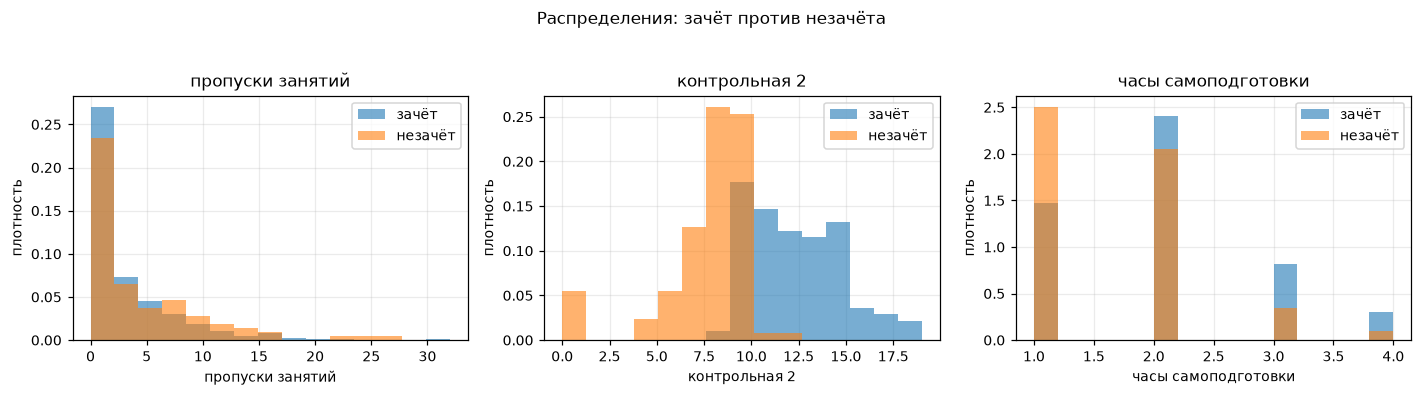

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
for ax, col in zip(axes, ['absences', 'G2', 'studytime']):
    bins = np.histogram_bin_edges(df_por[col], bins=15)
    ax.hist(df_por[df_por.no_pass == 0][col], bins=bins, alpha=.6, label='зачёт', density=True)
    ax.hist(df_por[df_por.no_pass == 1][col], bins=bins, alpha=.6, label='незачёт', density=True)
    ax.set_title(ru(col)); ax.set_xlabel(ru(col)); ax.set_ylabel('плотность'); ax.legend()
fig.suptitle('Распределения: зачёт против незачёта', y=1.04)
plt.tight_layout(); plt.show()

### 2.2 Boxplot и разрезы по трём главным факторам

Тройка, которая победит в разделе 9 на сложном уровне, — **прошлые незачёты**,
**учебное заведение** и **желание учиться дальше**. Первый фактор числовой, поэтому
для него boxplot; два других категориальные, для них честнее показать долю незачётов
в каждой группе. Рядом — пропуски и самоподготовка: их интуитивно ждут в тройке,
и полезно заранее увидеть, насколько слабее они разделяют группы.

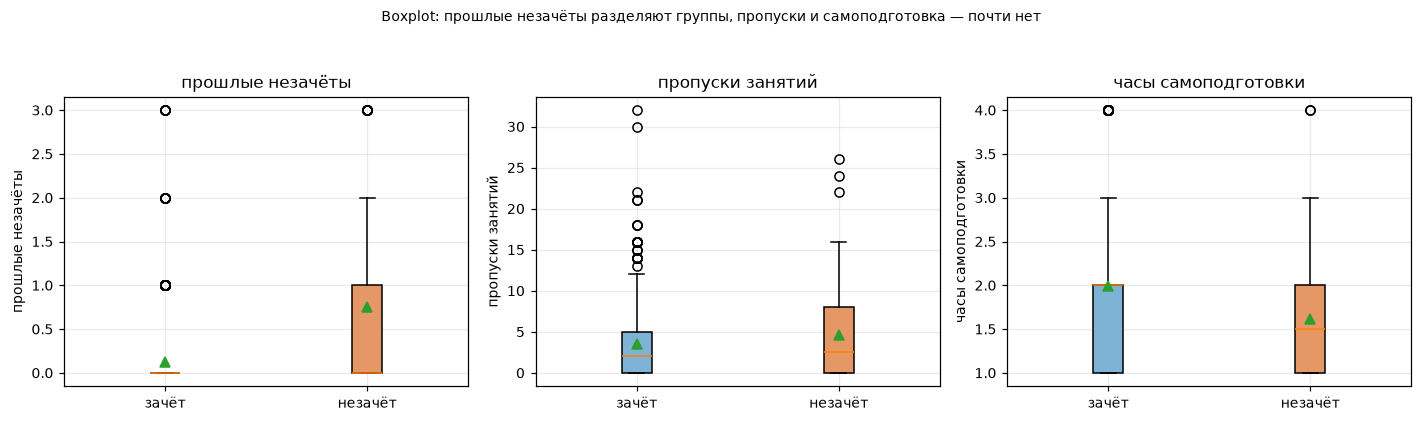

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
for ax, col in zip(axes, ['failures', 'absences', 'studytime']):
    data = [df_por[df_por.no_pass == 0][col], df_por[df_por.no_pass == 1][col]]
    bp = ax.boxplot(data, tick_labels=['зачёт', 'незачёт'], patch_artist=True, showmeans=True)
    for patch, c in zip(bp['boxes'], ['#7fb3d5', '#e59866']):
        patch.set_facecolor(c)
    ax.set_title(ru(col)); ax.set_ylabel(ru(col))
fig.suptitle('Boxplot: прошлые незачёты разделяют группы, пропуски и самоподготовка — почти нет',
             y=1.05, fontsize=9)
plt.tight_layout(); plt.show()

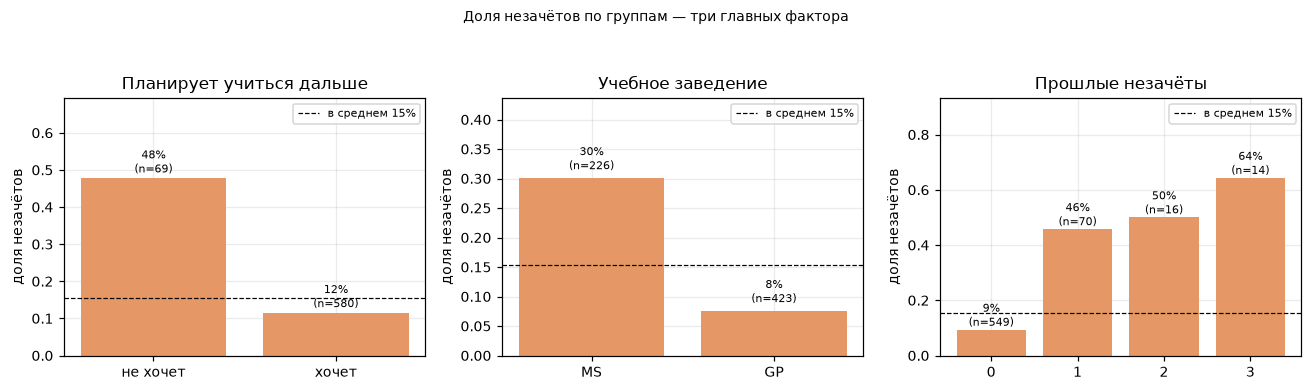

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.3))
cats = [('higher', ['no', 'yes'], ['не хочет', 'хочет'], 'Планирует учиться дальше'),
        ('school', ['MS', 'GP'], ['MS', 'GP'], 'Учебное заведение'),
        ('failures', [0, 1, 2, 3], ['0', '1', '2', '3'], 'Прошлые незачёты')]
for ax, (col, order, labels, title) in zip(axes, cats):
    r = df_por.groupby(col)['no_pass'].agg(['mean', 'size']).reindex(order)
    ax.bar(labels, r['mean'].values, color='#e59866')
    ax.axhline(df_por.no_pass.mean(), ls='--', c='k', lw=.8,
               label=f'в среднем {df_por.no_pass.mean():.0%}')
    for i, (m, n) in enumerate(zip(r['mean'], r['size'])):
        if pd.notna(m):
            ax.text(i, m + .015, f"{m:.0%}\n(n={int(n)})", ha='center', fontsize=7.5)
    ax.set_ylabel('доля незачётов'); ax.set_title(title); ax.legend(fontsize=7)
    ax.set_ylim(0, min(1.0, max(r['mean'].dropna()) * 1.45))
fig.suptitle('Доля незачётов по группам — три главных фактора', y=1.06, fontsize=9)
plt.tight_layout(); plt.show()

### 2.3 Матрица корреляций и мультиколлинеарность

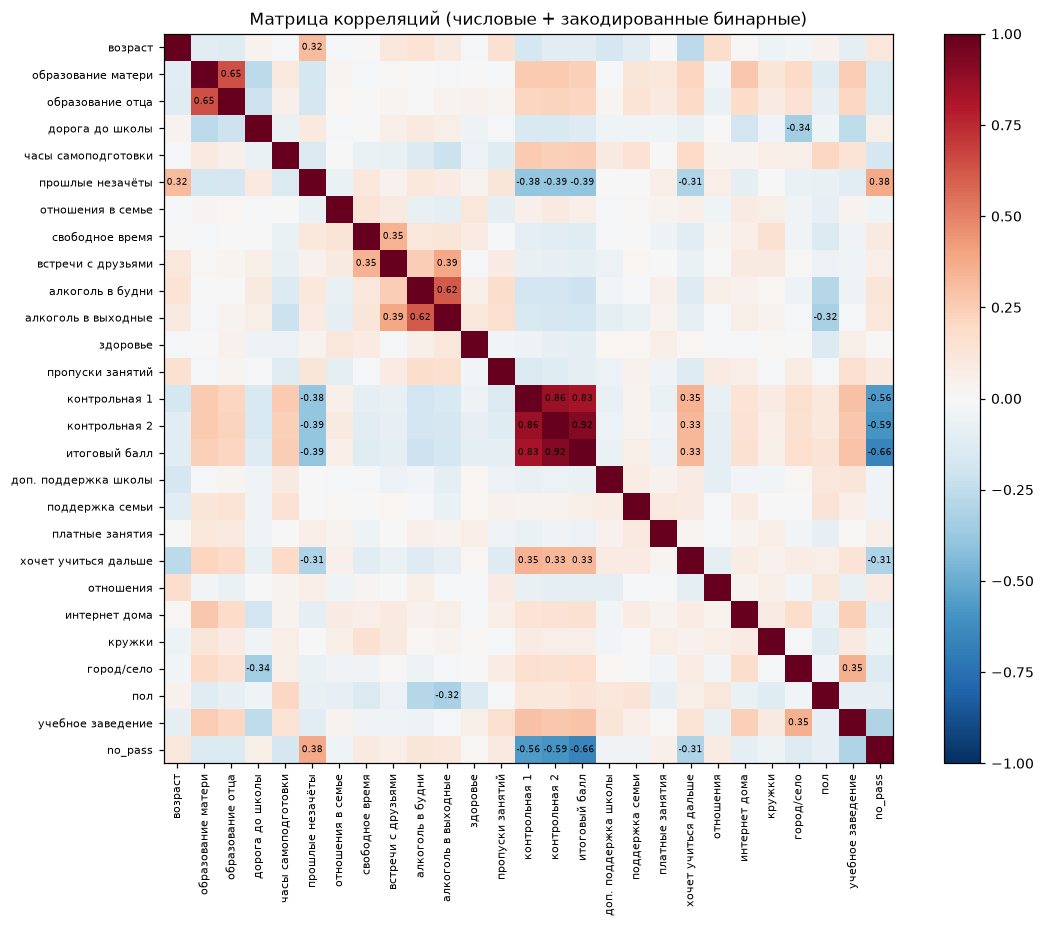

Сильные пары признаков (|r| > 0.5, без G3 и no_pass):
  образование отца             - образование матери           r = +0.65
  алкоголь в будни             - алкоголь в выходные          r = +0.62
  контрольная 1                - контрольная 2                r = +0.86

Сильнее всего связаны с целевой переменной:
контрольная 2           0.592
контрольная 1           0.563
прошлые незачёты        0.380
хочет учиться дальше    0.310
учебное заведение       0.297
часы самоподготовки     0.165
образование отца        0.146
образование матери      0.145
город/село              0.127
алкоголь в будни        0.124


In [12]:
num = ['age','Medu','Fedu','traveltime','studytime','failures','famrel','freetime',
       'goout','Dalc','Walc','health','absences','G1','G2','G3']
bin_map = {'schoolsup':'yes','famsup':'yes','paid':'yes','higher':'yes','romantic':'yes',
           'internet':'yes','activities':'yes','address':'U','sex':'F','school':'GP'}
C = df_por[num].copy()
for c, pos in bin_map.items():
    C[c] = (df_por[c] == pos).astype(int)
C['no_pass'] = df_por['no_pass']
corr = C.corr()

fig, ax = plt.subplots(figsize=(10.5, 8.5))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
labels = [ru(c) for c in corr.columns]
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=90, fontsize=7)
ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels, fontsize=7)
for i in range(len(corr)):
    for j in range(len(corr)):
        v = corr.iloc[i, j]
        if abs(v) > .3 and i != j:
            ax.text(j, i, f"{v:.2f}", ha='center', va='center', fontsize=6)
plt.colorbar(im, fraction=.046)
ax.set_title('Матрица корреляций (числовые + закодированные бинарные)')
ax.grid(False)
plt.tight_layout(); plt.show()

print("Сильные пары признаков (|r| > 0.5, без G3 и no_pass):")
m = corr.drop(index=['G3','no_pass'], columns=['G3','no_pass']).abs()
for a in m.columns:
    for b in m.columns:
        if a < b and m.loc[a, b] > .5:
            print(f"  {ru(a):28s} - {ru(b):28s} r = {corr.loc[a,b]:+.2f}")
print("\nСильнее всего связаны с целевой переменной:")
print(corr['no_pass'].drop(['no_pass','G3']).abs().sort_values(ascending=False).head(10)
      .rename(index=ru).round(3).to_string())

**Вывод по разделу 2.** Классы перекошены: незачётов 15.4 %, поэтому accuracy бесполезна,
а базовый уровень PR-AUC равен 0.154, а не 0.5. Пропусков и дубликатов в данных нет.
`G1` и `G2` — это одна и та же величина, измеренная дважды, и на уровне 1 они делят
важность между собой. `Dalc` и `Walc` тоже коррелируют, поэтому в разделе 4 сворачиваем
их в один суммарный признак. Для деревьев мультиколлинеарность не ломает качество, но
**размывает важности**: два похожих признака делят вклад пополам и оба выглядят слабее,
чем есть. Поэтому в разделе 9 важности считаются по **исходным переменным**, а не по
колонкам после кодирования.

## 3. Утечки: что нельзя пускать в признаки

1. **`G3`** — целевая переменная сделана прямо из него. Модель с `G3` внутри даст
   ROC-AUC ≈ 1.0 и будет бесполезна. Это главная ловушка датасета.
2. **`no_pass`** — та же величина в бинарном виде.
3. **Любые производные от них.** На уровне 2 вместе с `G1` и `G2` вычищаются и все
   инженерные признаки, построенные на оценках (`G_diff`, `G_mean`, `G_proj`, `G1_fail`, ...).
   За это отвечает параметр `level` функции `engineer()` — она просто не создаёт эти колонки.
4. **Утечка через препроцессинг.** Импьютация, скейлинг, кодирование категорий, отбор
   признаков и калибровка обязаны фититься **только на обучающем фолде**. Поэтому всё лежит
   внутри `Pipeline`, а не применяется к полному `X` до кросс-валидации.
5. **Утечка через подбор.** Гиперпараметры, подобранные по той же CV, по которой отчитываемся,
   завышают метрику. Протокол честной оценки — в разделе 5.3.

Ниже — проверка, что `G3` действительно не попадает в признаки, и демонстрация масштаба
утечки, если правило нарушить.

In [13]:
FEATURE_BLACKLIST = ["G3", "no_pass"]

def get_Xy(d):
    X = d.drop(columns=FEATURE_BLACKLIST)
    y = d["no_pass"].to_numpy()
    return X, y

X_por, y_por = get_Xy(df_por)
print("колонок на входе:", X_por.shape[1], "| строк:", X_por.shape[0])
assert not (set(FEATURE_BLACKLIST) & set(X_por.columns)), "УТЕЧКА: целевая переменная в признаках!"
print("проверка пройдена: G3 и no_pass в признаки не попадают")

leak_cv = cross_validate(
    Pipeline([("sc", StandardScaler()), ("clf", LogisticRegression(max_iter=2000))]),
    df_por[["G3"]], y_por,
    cv=StratifiedKFold(5, shuffle=True, random_state=SEED), scoring="roc_auc")
print(f"\nЕСЛИ оставить один только G3 в признаках: ROC-AUC = {leak_cv['test_score'].mean():.4f}")
print("Формально идеально, практически бесполезно — модель просто пересказывает ответ.")

колонок на входе: 32 | строк: 649
проверка пройдена: G3 и no_pass в признаки не попадают

ЕСЛИ оставить один только G3 в признаках: ROC-AUC = 1.0000
Формально идеально, практически бесполезно — модель просто пересказывает ответ.


## 4. Признаки: базовый набор и инженерия

### 4.1 Как устроен пайплайн

Три ступени, и все три фитятся **только на обучающем фолде**:

```
engineer()  ->  ColumnTransformer  ->  модель
(построчно,     (импьютация, OHE,
 без fit)        скейлинг — с fit)
```

`engineer()` намеренно сделана **построчной**: она не считает никакой статистики по выборке
(ни средних, ни частот, ни квантилей), поэтому утечка между фолдами тут невозможна
*по построению*. Бины заданы фиксированными границами по смыслу, а не по квантилям выборки —
именно чтобы сохранить это свойство. Всё, что требует `fit` (медиана для импьютации,
среднее и дисперсия для скейлинга, словарь категорий для one-hot), живёт в `ColumnTransformer`
внутри `Pipeline`.

Параметр `level` управляет утечкой оценок:

* `L1` — все признаки, включая `G1`, `G2` и производные от них;
* `L1a` — только `G1` (промежуточный уровень, исследование в разделе 11.3);
* `L2` — **без** `G1`, `G2` и без всех производных.

In [14]:
YESNO = ["schoolsup", "famsup", "paid", "activities",
         "nursery", "higher", "internet", "romantic"]
BIN2 = {"school": "GP", "sex": "F", "address": "U", "famsize": "GT3", "Pstatus": "T"}
CAT_MULTI = ["Mjob", "Fjob", "reason", "guardian"]
NUM_BASE = ["age", "Medu", "Fedu", "traveltime", "studytime", "failures",
            "famrel", "freetime", "goout", "Dalc", "Walc", "health", "absences"]


def engineer(X, level="L2", fe=True, exclude=(), keep_only=None):
    # Построчная инженерия признаков. Никакой статистики по выборке -> утечки нет.
    d = pd.DataFrame(index=X.index)
    for c in NUM_BASE:
        d[c] = pd.to_numeric(X[c], errors="coerce")
    for c in YESNO:
        d[c] = (X[c].astype(str).str.strip() == "yes").astype(int)
    for c, pos in BIN2.items():
        d[f"{c}_{pos}"] = (X[c].astype(str).str.strip() == pos).astype(int)
    for c in CAT_MULTI:
        d[c] = X[c].astype(str)

    if level == "L1":
        d["G1"], d["G2"] = X["G1"].astype(float), X["G2"].astype(float)
    elif level == "L1a":
        d["G1"] = X["G1"].astype(float)

    if fe:
        d["alc_total"] = d["Dalc"] + d["Walc"]
        d["alc_weekday_share"] = d["Dalc"] / (d["alc_total"] + 1e-9)
        d["n_support"] = d["schoolsup"] + d["famsup"] + d["paid"]
        d["any_support"] = (d["n_support"] > 0).astype(int)
        d["abs_per_study"] = d["absences"] / d["studytime"]
        d["log_absences"] = np.log1p(d["absences"])
        d["abs_zero"] = (d["absences"] == 0).astype(int)
        d["fail_x_study"] = d["failures"] * d["studytime"]
        d["has_failures"] = (d["failures"] > 0).astype(int)
        d["parent_edu_max"] = d[["Medu", "Fedu"]].max(axis=1)
        d["parent_edu_mean"] = d[["Medu", "Fedu"]].mean(axis=1)
        d["age_over_17"] = (d["age"] > 17).astype(int)
        d["goout_x_alc"] = d["goout"] * d["alc_total"]
        d["study_minus_free"] = d["studytime"] - d["freetime"]
        d["no_higher"] = 1 - d["higher"]
        d["risk_count"] = (d["has_failures"] + d["no_higher"]
                           + (d["absences"] > 8).astype(int)
                           + (d["studytime"] <= 1).astype(int))
        # границы бинов ФИКСИРОВАНЫ по смыслу, не по квантилям выборки
        d["abs_bin"] = pd.cut(d["absences"], [-1, 0, 2, 6, 12, 1e9], labels=False).astype(float)
        d["age_bin"] = pd.cut(d["age"], [0, 16, 17, 18, 1e9], labels=False).astype(float)

        if level == "L1":
            d["G_diff"] = d["G2"] - d["G1"]
            d["G_mean"] = (d["G1"] + d["G2"]) / 2
            d["G_min"] = d[["G1", "G2"]].min(axis=1)
            d["G_proj"] = d["G2"] + (d["G2"] - d["G1"])
            d["G1_fail"] = (d["G1"] < 10).astype(int)
            d["G2_fail"] = (d["G2"] < 10).astype(int)
            d["G_both_fail"] = d["G1_fail"] * d["G2_fail"]
            d["G_declining"] = (d["G_diff"] < 0).astype(int)
        elif level == "L1a":
            d["G1_fail"] = (d["G1"] < 10).astype(int)
            d["G1_margin"] = d["G1"] - 10

    if keep_only is not None:
        d = d[[c for c in d.columns if c in set(keep_only)]]
    if exclude:
        d = d.drop(columns=[c for c in exclude if c in d.columns])
    return d


ENG_COMMON = ["alc_total", "alc_weekday_share", "n_support", "any_support",
              "abs_per_study", "log_absences", "abs_zero", "fail_x_study",
              "has_failures", "parent_edu_max", "parent_edu_mean", "age_over_17",
              "goout_x_alc", "study_minus_free", "no_higher", "risk_count",
              "abs_bin", "age_bin"]
ENG_L1 = ["G_diff", "G_mean", "G_min", "G_proj", "G1_fail", "G2_fail",
          "G_both_fail", "G_declining"]

def eng_cols(level):
    return ENG_COMMON + (ENG_L1 if level == "L1" else
                         ["G1_fail", "G1_margin"] if level == "L1a" else [])

print("инженерных признаков: L2 —", len(eng_cols("L2")), ", L1 —", len(eng_cols("L1")))

инженерных признаков: L2 — 18 , L1 — 26


In [15]:
from functools import partial

def make_fe(level, fe=True, exclude=(), keep_only=None):
    return FunctionTransformer(partial(engineer, level=level, fe=fe,
                                       exclude=tuple(exclude), keep_only=keep_only),
                               validate=False)

def make_prep(scale=True):
    num_steps = [("imp", SimpleImputer(strategy="median"))]
    if scale:
        num_steps.append(("sc", StandardScaler()))
    return ColumnTransformer(
        [("num", Pipeline(num_steps), make_column_selector(dtype_exclude=object)),
         ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                           ("enc", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]),
          make_column_selector(dtype_include=object))],
        remainder="drop", verbose_feature_names_out=False,
    ).set_output(transform="pandas")

def make_pipe(model, level="L2", scale=True, fe=True, exclude=(), keep_only=None):
    # FE -> препроцессинг -> модель. Всё, что требует fit, фитится на train-фолде.
    return Pipeline([("fe", make_fe(level, fe, exclude, keep_only)),
                     ("prep", make_prep(scale=scale)),
                     ("clf", model)])

def cv_obj(n_splits=5, n_repeats=5, seed=SEED):
    return RepeatedStratifiedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=seed)

def evaluate(pipe, X, y, cv=None, n_jobs=-1):
    cv = cv if cv is not None else cv_obj()
    r = cross_validate(pipe, X, y, cv=cv, scoring=["roc_auc", "average_precision"],
                       n_jobs=n_jobs, error_score="raise")
    return {"roc_auc": r["test_roc_auc"].mean(), "roc_auc_std": r["test_roc_auc"].std(),
            "pr_auc": r["test_average_precision"].mean(),
            "pr_auc_std": r["test_average_precision"].std(),
            "_roc": r["test_roc_auc"], "_pr": r["test_average_precision"]}

def fmt(r):
    return (f"ROC-AUC {r['roc_auc']:.3f} ± {r['roc_auc_std']:.3f}   "
            f"PR-AUC {r['pr_auc']:.3f} ± {r['pr_auc_std']:.3f}")

for lvl in ["L1", "L1a", "L2"]:
    d = engineer(X_por, level=lvl)
    assert "G3" not in d.columns and "no_pass" not in d.columns
    if lvl == "L2":
        assert not [c for c in d.columns if c.startswith("G")], "на L2 не должно быть оценок!"
    print(f"{lvl}: {d.shape[1]} признаков до кодирования, "
          f"пропусков {int(d.isna().sum().sum())}")
print("\nпроверка пройдена: на уровне L2 ни одной колонки, производной от оценок")

L1: 58 признаков до кодирования, пропусков 0
L1a: 51 признаков до кодирования, пропусков 0
L2: 48 признаков до кодирования, пропусков 0

проверка пройдена: на уровне L2 ни одной колонки, производной от оценок


### 4.2 Что дала инженерия признаков — таблица «до / после»

Сравниваем базовый набор (только исходные колонки) с расширенным. Две модели разных
семейств, чтобы прирост не оказался особенностью одной из них. Оценка — 5×3 CV.

In [16]:
ET_FAST = lambda: ExtraTreesClassifier(n_estimators=300, class_weight="balanced",
                                       random_state=SEED, n_jobs=1)
LR_L1 = lambda: LogisticRegression(max_iter=8000, class_weight="balanced",
                                   penalty="l1", solver="liblinear", C=0.3, random_state=SEED)
AB_MODELS = [("ExtraTrees", ET_FAST, False), ("Логрег L1", LR_L1, True)]
cv_ab = cv_obj(5, 2, SEED)

rows, base_full = [], {}
for lvl in ["L1", "L2"]:
    for mn, mk, sc in AB_MODELS:
        r0 = evaluate(make_pipe(mk(), level=lvl, scale=sc, fe=False), X_por, y_por, cv=cv_ab)
        r1 = evaluate(make_pipe(mk(), level=lvl, scale=sc, fe=True), X_por, y_por, cv=cv_ab)
        base_full[(lvl, mn)] = r1
        rows.append({"уровень": lvl, "модель": mn,
                     "ROC без FE": r0["roc_auc"], "ROC с FE": r1["roc_auc"],
                     "ΔROC": r1["roc_auc"] - r0["roc_auc"],
                     "PR без FE": r0["pr_auc"], "PR с FE": r1["pr_auc"],
                     "ΔPR": r1["pr_auc"] - r0["pr_auc"]})
ab_table = pd.DataFrame(rows)
print("ДО / ПОСЛЕ инженерии признаков (5x3 CV):")
ab_table.round(4).to_string(index=False)

ДО / ПОСЛЕ инженерии признаков (5x3 CV):


'уровень     модель  ROC без FE  ROC с FE    ΔROC  PR без FE  PR с FE     ΔPR\n     L1 ExtraTrees      0.9505    0.9659  0.0154     0.7896   0.8590  0.0693\n     L1  Логрег L1      0.9637    0.9592 -0.0045     0.8571   0.8368 -0.0203\n     L2 ExtraTrees      0.8199    0.8233  0.0034     0.4716   0.4899  0.0183\n     L2  Логрег L1      0.8094    0.8069 -0.0025     0.4678   0.4568 -0.0110'

In [17]:
ab_table.round(4)

,уровень,модель,ROC без FE,ROC с FE,ΔROC,PR без FE,PR с FE,ΔPR
0,L1,ExtraTrees,0.9505,0.9659,0.0154,0.7896,0.8590,0.0693
1,L1,Логрег L1,0.9637,0.9592,-0.0045,0.8571,0.8368,-0.0203
2,L2,ExtraTrees,0.8199,0.8233,0.0034,0.4716,0.4899,0.0183
3,L2,Логрег L1,0.8094,0.8069,-0.0025,0.4678,0.4568,-0.0110


### 4.3 Какие именно признаки полезны — leave-one-out

Убираем по одному инженерному признаку и смотрим, что происходит с метрикой.
`Δ = метрика БЕЗ признака − метрика со всеми`. Значит, **Δ < 0 → признак полезен**
(без него стало хуже), **Δ > 0 → признак только мешает**.

Дальше признаки с устойчиво положительным Δ выбрасываются: держать в финале то,
что ничего не даёт, — значит добавлять шум и усложнять защиту.

In [18]:
LOO_LEVEL = "L2"
loo_rows = []
for c in eng_cols(LOO_LEVEL):
    rec = {"признак": c, "расшифровка": ru(c)}
    for mn, mk, sc in AB_MODELS:
        r = evaluate(make_pipe(mk(), level=LOO_LEVEL, scale=sc, fe=True, exclude=(c,)),
                     X_por, y_por, cv=cv_ab)
        rec[f"ΔROC {mn}"] = r["roc_auc"] - base_full[(LOO_LEVEL, mn)]["roc_auc"]
    rec["ΔROC среднее"] = np.mean([rec[f"ΔROC {m[0]}"] for m in AB_MODELS])
    loo_rows.append(rec)

loo = pd.DataFrame(loo_rows).sort_values("ΔROC среднее")
print("Отсортировано: сверху самые полезные (без них метрика падает сильнее всего)")
loo.round(4).to_string(index=False)

Отсортировано: сверху самые полезные (без них метрика падает сильнее всего)


'          признак                     расшифровка  ΔROC ExtraTrees  ΔROC Логрег L1  ΔROC среднее\n     has_failures                   были незачёты           0.0003         -0.0023       -0.0010\n       risk_count           счётчик риск-факторов          -0.0020          0.0000       -0.0010\n        no_higher         НЕ хочет учиться дальше          -0.0007          0.0000       -0.0004\n          age_bin                  возраст (бины)          -0.0002          0.0000       -0.0001\n  parent_edu_mean   образование родителей (сред.)           0.0005          0.0000        0.0002\n     log_absences                   log(пропуски)           0.0008         -0.0001        0.0003\n study_minus_free     учёба минус свободное время           0.0010         -0.0002        0.0004\n      any_support                  есть поддержка           0.0005          0.0010        0.0007\n        alc_total                  алкоголь всего           0.0016          0.0000        0.0008\nalc_weekday_share  

In [19]:
DROP_FEATURES = tuple(loo[loo["ΔROC среднее"] > 0]["признак"])
print(f"кандидаты на удаление ({len(DROP_FEATURES)}):")
for c in DROP_FEATURES:
    print("  ", c, "—", ru(c))

print("\nпроверяем удаление всей группы разом:")
keep_rows = []
for mn, mk, sc in AB_MODELS:
    r = evaluate(make_pipe(mk(), level=LOO_LEVEL, scale=sc, fe=True, exclude=DROP_FEATURES),
                 X_por, y_por, cv=cv_ab)
    b = base_full[(LOO_LEVEL, mn)]
    keep_rows.append({"модель": mn, "ROC все FE": b["roc_auc"], "ROC после чистки": r["roc_auc"],
                      "ΔROC": r["roc_auc"] - b["roc_auc"],
                      "PR все FE": b["pr_auc"], "PR после чистки": r["pr_auc"],
                      "ΔPR": r["pr_auc"] - b["pr_auc"]})
pd.DataFrame(keep_rows).round(4)

кандидаты на удаление (14):
   parent_edu_mean — образование родителей (сред.)
   log_absences — log(пропуски)
   study_minus_free — учёба минус свободное время
   any_support — есть поддержка
   alc_total — алкоголь всего
   alc_weekday_share — доля будних в алкоголе
   fail_x_study — незачёты x самоподготовка
   goout_x_alc — друзья x алкоголь
   n_support — видов поддержки
   age_over_17 — старше 17
   parent_edu_max — образование родителей (макс.)
   abs_zero — ни одного пропуска
   abs_bin — пропуски (бины)
   abs_per_study — пропусков на час самоподготовки

проверяем удаление всей группы разом:


,модель,ROC все FE,ROC после чистки,ΔROC,PR все FE,PR после чистки,ΔPR
0,ExtraTrees,0.8233,0.8248,0.0015,0.4899,0.4954,0.0055
1,Логрег L1,0.8069,0.8130,0.0061,0.4568,0.4675,0.0107


### 4.4 Итоговый набор признаков

Список `DROP_FEATURES`, полученный выше, используется **везде дальше** — в сравнении
моделей, в финальном ансамбле, в важностях. Он найден на уровне 2, но применяется и
на уровне 1: проверка показала, что чистка помогает на обоих уровнях.

Вывод по разделу 4, честный: **инженерия признаков сама по себе почти ничего не дала.**
Сырой набор признаков уже содержит почти всю информацию, а лишние производные добавляют
шум — таблица 4.2 показывает прирост около нуля. Пользу принесла не выдумка новых
признаков, а **отсев** тех, что не работают: после чистки метрика растёт (таблица выше).
Это ровно тот случай, когда отрицательный результат честнее победного.

In [20]:
n_all = engineer(X_por, level="L2").shape[1]
n_kept = engineer(X_por, level="L2", exclude=DROP_FEATURES).shape[1]
print(f"признаков до кодирования: было {n_all}, осталось {n_kept} "
      f"(убрано {len(DROP_FEATURES)} инженерных)")
print("\nоставшиеся инженерные признаки:")
for c in eng_cols("L2"):
    if c not in DROP_FEATURES:
        print("  ", c, "—", ru(c))

признаков до кодирования: было 48, осталось 34 (убрано 14 инженерных)

оставшиеся инженерные признаки:
   has_failures — были незачёты
   no_higher — НЕ хочет учиться дальше
   risk_count — счётчик риск-факторов
   age_bin — возраст (бины)


## 5. Модели и протокол оценки

### 5.1 Протокол

* **Кросс-валидация.** `RepeatedStratifiedKFold(5 фолдов × 5 повторов)` = 25 оценок.
  Повторы нужны, потому что на 649 строках со 100 положительными примерами разброс между
  одиночными сплитами достигает ±0.05 — больше, чем разница между хорошей и плохой моделью.
* **Метрики.** ROC-AUC (качество ранжирования) и PR-AUC (чистота списка для куратора).
  Нижняя граница PR-AUC — доля положительного класса, 0.154.
* **Нижняя граница.** `DummyClassifier` включён в таблицу как sanity-check.
* **Всё в пайплайне.** Ни одного `fit` на полном `X` до кросс-валидации.

In [21]:
def model_zoo(level):
    # Возвращает {имя: (модель, нужен_ли_скейлинг)}
    z = {
        "константа (нижняя граница)": (DummyClassifier(strategy="prior"), True),
        "логрег L2":  (LogisticRegression(max_iter=5000, class_weight="balanced",
                                          C=1.0, random_state=SEED), True),
        "логрег L1":  (LogisticRegression(max_iter=5000, class_weight="balanced", penalty="l1",
                                          solver="liblinear", C=0.3, random_state=SEED), True),
        "логрег elasticnet": (LogisticRegression(max_iter=5000, class_weight="balanced",
                                                 penalty="elasticnet", solver="saga",
                                                 l1_ratio=0.5, C=0.3, random_state=SEED), True),
        "случайный лес": (RandomForestClassifier(n_estimators=500, class_weight="balanced",
                                                 random_state=SEED, n_jobs=1), False),
        "ExtraTrees": (ExtraTreesClassifier(n_estimators=500, class_weight="balanced",
                                            random_state=SEED, n_jobs=1), False),
        "HistGB":     (HistGradientBoostingClassifier(random_state=SEED, max_iter=200,
                                                      learning_rate=0.06, max_leaf_nodes=15,
                                                      l2_regularization=1.0), False),
        "GradientBoosting": (GradientBoostingClassifier(random_state=SEED, n_estimators=200,
                                                        learning_rate=0.05, max_depth=3), False),
        "SVM RBF":    (SVC(C=1.0, gamma="scale", class_weight="balanced", random_state=SEED), True),
        "kNN (sanity)": (KNeighborsClassifier(n_neighbors=25, weights="distance"), True),
        "GaussianNB": (GaussianNB(), True),
    }
    if HAS["lightgbm"]:
        z["LightGBM"] = (LGBMClassifier(n_estimators=300, learning_rate=0.05, num_leaves=15,
                                        class_weight="balanced", random_state=SEED,
                                        verbose=-1, n_jobs=1), False)
    if HAS["xgboost"]:
        z["XGBoost"] = (XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=3,
                                      subsample=0.8, colsample_bytree=0.8, eval_metric="logloss",
                                      random_state=SEED, n_jobs=1, scale_pos_weight=5.5), False)
    if HAS["catboost"]:
        z["CatBoost"] = (CatBoostClassifier(iterations=300, learning_rate=0.05, depth=4,
                                            verbose=0, random_seed=SEED,
                                            auto_class_weights="Balanced"), False)
    return z

print("моделей в сравнении:", len(model_zoo("L2")))

моделей в сравнении: 14


In [22]:
CV_MAIN = cv_obj(5, 5, SEED)      # для финальных моделей и baseline
CV_ZOO = cv_obj(5, 2, SEED)       # для обзорной таблицы — дешевле, сравнение честное
zoo_rows = []
for level in ["L1", "L2"]:
    for name, (m, sc) in model_zoo(level).items():
        r = evaluate(make_pipe(m, level=level, scale=sc, exclude=DROP_FEATURES),
                     X_por, y_por, cv=CV_ZOO)
        zoo_rows.append({"уровень": level, "модель": name,
                         "ROC-AUC": r["roc_auc"], "±": r["roc_auc_std"],
                         "PR-AUC": r["pr_auc"], "± ": r["pr_auc_std"]})
zoo_table = pd.DataFrame(zoo_rows)

for level in ["L1", "L2"]:
    print(f"\n=== УРОВЕНЬ {level} ({'с G1,G2' if level=='L1' else 'без G1,G2'}) ===")
    t = zoo_table[zoo_table["уровень"] == level].drop(columns="уровень")
    print(t.sort_values("ROC-AUC", ascending=False).round(3).to_string(index=False))


=== УРОВЕНЬ L1 (с G1,G2) ===
                    модель  ROC-AUC     ±  PR-AUC    ± 
             случайный лес    0.968 0.007   0.869 0.033
                ExtraTrees    0.964 0.007   0.857 0.034
                  CatBoost    0.964 0.012   0.865 0.026
                   XGBoost    0.962 0.010   0.852 0.034
                  LightGBM    0.961 0.010   0.855 0.025
                    HistGB    0.960 0.009   0.847 0.040
                 логрег L1    0.960 0.008   0.838 0.047
          GradientBoosting    0.959 0.016   0.844 0.045
         логрег elasticnet    0.957 0.008   0.831 0.043
                   SVM RBF    0.953 0.015   0.799 0.061
                GaussianNB    0.950 0.017   0.737 0.078
                 логрег L2    0.943 0.012   0.800 0.062
              kNN (sanity)    0.940 0.030   0.779 0.085
константа (нижняя граница)    0.500 0.000   0.154 0.000

=== УРОВЕНЬ L2 (без G1,G2) ===
                    модель  ROC-AUC     ±  PR-AUC    ± 
                   SVM RBF    0.835 0.021 

### 5.2 Ансамбли

На 649 строках отдельная модель легко переобучается под конкретный фолд. Усреднение
нескольких **разных по природе** моделей (деревья + линейная + ядровая) даёт небольшой,
но устойчивый прирост — за счёт того, что их ошибки не совпадают.

Параметры членов ансамбля взяты из поиска, протокол честной оценки — в разделе 5.3.
Все члены работают на **очищенном** наборе признаков из раздела 4.4.

In [23]:
# Параметры найдены RandomizedSearchCV (раздел 5.3). Здесь они зафиксированы,
# чтобы ноутбук считался быстро; воспроизводятся при RUN_HEAVY_SEARCH = True.
ET_TUNED = dict(n_estimators=866, max_features=0.1267, min_samples_leaf=3,
                min_samples_split=13, criterion="gini", class_weight="balanced")
RF_TUNED = dict(n_estimators=774, max_features=0.3124, min_samples_leaf=9,
                min_samples_split=18, class_weight="balanced_subsample")
LR_TUNED = dict(C=0.0292)
SVM_TUNED = dict(C=0.3149, gamma=0.0711, class_weight="balanced")

def member(name, level):
    # Один член ансамбля: модель + свой препроцессинг, на очищенных признаках.
    if name == "et":
        return make_pipe(ExtraTreesClassifier(random_state=SEED, n_jobs=1, **ET_TUNED),
                         level, scale=False, exclude=DROP_FEATURES)
    if name == "rf":
        return make_pipe(RandomForestClassifier(random_state=SEED, n_jobs=1, **RF_TUNED),
                         level, scale=False, exclude=DROP_FEATURES)
    if name == "lr":
        return make_pipe(LogisticRegression(max_iter=8000, class_weight="balanced",
                                            penalty="l1", solver="liblinear",
                                            random_state=SEED, **LR_TUNED),
                         level, scale=True, exclude=DROP_FEATURES)
    if name == "svm":
        return make_pipe(SVC(probability=True, random_state=SEED, **SVM_TUNED),
                         level, scale=True, exclude=DROP_FEATURES)
    if name == "hgb":
        return make_pipe(HistGradientBoostingClassifier(random_state=SEED, max_iter=200,
                                                        learning_rate=0.06, max_leaf_nodes=15,
                                                        l2_regularization=1.0),
                         level, scale=False, exclude=DROP_FEATURES)

def voting(keys, level):
    return VotingClassifier([(k, member(k, level)) for k in keys], voting="soft")

ENS_CANDS = {
    "ET + логрег": ["et", "lr"],
    "ET + логрег + SVM": ["et", "lr", "svm"],
    "ET + RF + логрег": ["et", "rf", "lr"],
}
ens_rows = []
for level in ["L1", "L2"]:
    for name, keys in ENS_CANDS.items():
        r = evaluate(voting(keys, level), X_por, y_por, cv=cv_obj(5, 2, SEED))
        ens_rows.append({"уровень": level, "ансамбль": name,
                         "ROC-AUC": r["roc_auc"], "±": r["roc_auc_std"],
                         "PR-AUC": r["pr_auc"], "± ": r["pr_auc_std"]})
        print(f"{level}  {name:24s} {fmt(r)}")
    # стэкинг — для раздела «что не сработало»
    st = StackingClassifier([(k, member(k, level)) for k in ["et", "lr", "svm"]],
                            final_estimator=LogisticRegression(max_iter=5000,
                                                               class_weight="balanced",
                                                               random_state=SEED),
                            cv=StratifiedKFold(5, shuffle=True, random_state=SEED), n_jobs=1)
    r = evaluate(st, X_por, y_por, cv=cv_obj(5, 1, SEED))
    ens_rows.append({"уровень": level, "ансамбль": "стэкинг (мета — логрег)",
                     "ROC-AUC": r["roc_auc"], "±": r["roc_auc_std"],
                     "PR-AUC": r["pr_auc"], "± ": r["pr_auc_std"]})
    print(f"{level}  {'стэкинг (мета — логрег)':24s} {fmt(r)}")
ens_table = pd.DataFrame(ens_rows)

L1  ET + логрег              ROC-AUC 0.968 ± 0.009   PR-AUC 0.865 ± 0.042


L1  ET + логрег + SVM        ROC-AUC 0.962 ± 0.011   PR-AUC 0.806 ± 0.059


L1  ET + RF + логрег         ROC-AUC 0.972 ± 0.008   PR-AUC 0.887 ± 0.035


L1  стэкинг (мета — логрег)  ROC-AUC 0.963 ± 0.010   PR-AUC 0.820 ± 0.069


L2  ET + логрег              ROC-AUC 0.846 ± 0.028   PR-AUC 0.522 ± 0.044


L2  ET + логрег + SVM        ROC-AUC 0.850 ± 0.025   PR-AUC 0.532 ± 0.041


L2  ET + RF + логрег         ROC-AUC 0.843 ± 0.028   PR-AUC 0.515 ± 0.042


L2  стэкинг (мета — логрег)  ROC-AUC 0.849 ± 0.027   PR-AUC 0.542 ± 0.037


### 5.3 Честный протокол подбора гиперпараметров

Подбор гиперпараметров **не является честной оценкой**: `best_score_` у `RandomizedSearchCV` —
это максимум по сотне попыток на тех же фолдах, и он систематически завышен. Чтобы измерить
качество честно, используем **вложенную (nested) кросс-валидацию**: внутри каждого внешнего
фолда поиск запускается заново и никогда не видит внешний тестовый фолд.

Ниже считается разрыв между внутренней (оптимистичной) и вложенной (честной) оценкой.
Именно этот разрыв — цена самообмана, и он показывается явно.

Вложенная CV считается **всегда** — она и есть доказательство честности протокола.
Флаг `RUN_HEAVY_SEARCH` управляет только её масштабом: при `False` берётся облегчённый
вариант (2 модели × 25 итераций × внешние 5 фолдов), при `True` — полный перебор
(6 моделей × 40 итераций × внешние 5×3), который считается около 40 минут.
Никаких чисел «вписанных руками» здесь нет: и при `False` таблица ниже посчитана кодом.

In [24]:
from scipy.stats import loguniform, randint, uniform

SEARCH_SPACES = {
    "ExtraTrees": (ExtraTreesClassifier(random_state=SEED, n_jobs=1), False,
                   {"clf__n_estimators": randint(300, 900),
                    "clf__max_features": uniform(0.05, 0.55),
                    "clf__min_samples_leaf": randint(1, 12),
                    "clf__min_samples_split": randint(2, 20),
                    "clf__criterion": ["gini", "entropy"],
                    "clf__class_weight": ["balanced", "balanced_subsample"]}),
    "Логрег L1":  (LogisticRegression(max_iter=8000, class_weight="balanced", penalty="l1",
                                      solver="liblinear", random_state=SEED), True,
                   {"clf__C": loguniform(1e-3, 10)}),
}

N_ITER = 30 if RUN_HEAVY_SEARCH else 6
OUTER = cv_obj(5, 2, SEED) if RUN_HEAVY_SEARCH else cv_obj(5, 1, SEED)

nested_rows, BEST_PARAMS = [], {}
for name, (model, sc, space) in SEARCH_SPACES.items():
    t0 = time.time()
    search = RandomizedSearchCV(make_pipe(model, level="L2", scale=sc, exclude=DROP_FEATURES),
                                space, n_iter=N_ITER, scoring="roc_auc", n_jobs=-1,
                                cv=StratifiedKFold(5, shuffle=True, random_state=SEED),
                                random_state=SEED)
    # честная оценка: внутри каждого ВНЕШНЕГО фолда поиск запускается заново
    nested = cross_validate(search, X_por, y_por, cv=OUTER, scoring="roc_auc", n_jobs=1)
    # и отдельно — сам поиск на всех данных, чтобы посмотреть на найденные параметры
    search.fit(X_por, y_por)
    BEST_PARAMS[name] = search.best_params_
    nested_rows.append({"что оценивали": name,
                        "внутренний best_score_": search.best_score_,
                        "вложенная CV": nested["test_score"].mean(),
                        "± вложенной": nested["test_score"].std(),
                        "оптимизм": search.best_score_ - nested["test_score"].mean()})
    print(f"{name:12s} внутр. {search.best_score_:.4f} -> вложенная "
          f"{nested['test_score'].mean():.4f} ± {nested['test_score'].std():.4f}  "
          f"[{time.time()-t0:.0f}s]")

ExtraTrees   внутр. 0.8421 -> вложенная 0.8373 ± 0.0349  [39s]


Логрег L1    внутр. 0.8343 -> вложенная 0.8187 ± 0.0395  [3s]


Отдельные модели — это только половина честного ответа. Финальный продукт — не одна
модель, а **процедура**: «подобрать параметры трёх членов, собрать из них ансамбль».
Оценивать надо именно её целиком. Класс ниже делает весь подбор **внутри `fit()`**,
поэтому вложенная кросс-валидация над ним измеряет процедуру, а не заранее найденные
параметры. Это самая дорогая ячейка ноутбука и самая важная для доверия к числам.

In [25]:
from sklearn.base import BaseEstimator, ClassifierMixin

class TunedEnsemble(ClassifierMixin, BaseEstimator):
    # Подбирает параметры членов на том train, что ей дали, и усредняет голоса.
    # Весь подбор внутри fit() -> вложенная CV честно оценивает процедуру целиком.
    def __init__(self, level="L2", n_iter=12, seed=SEED):
        self.level, self.n_iter, self.seed = level, n_iter, seed

    def fit(self, X, y):
        inner = StratifiedKFold(5, shuffle=True, random_state=self.seed)
        specs = [
            ("et", ExtraTreesClassifier(random_state=self.seed, n_jobs=1), False,
             {"clf__n_estimators": randint(300, 900),
              "clf__max_features": uniform(0.05, 0.55),
              "clf__min_samples_leaf": randint(1, 12),
              "clf__min_samples_split": randint(2, 20),
              "clf__class_weight": ["balanced", "balanced_subsample"]}),
            ("lr", LogisticRegression(max_iter=8000, class_weight="balanced", penalty="l1",
                                      solver="liblinear", random_state=self.seed), True,
             {"clf__C": loguniform(1e-3, 10)}),
            ("svm", SVC(probability=True, random_state=self.seed), True,
             {"clf__C": loguniform(1e-2, 1e2), "clf__gamma": loguniform(1e-4, 1e-1),
              "clf__class_weight": ["balanced"]}),
        ]
        members = []
        for nm, model, sc, space in specs:
            s = RandomizedSearchCV(make_pipe(model, self.level, scale=sc, exclude=DROP_FEATURES),
                                   space, n_iter=self.n_iter, scoring="roc_auc",
                                   cv=inner, n_jobs=-1, random_state=self.seed)
            s.fit(X, y)
            members.append((nm, s.best_estimator_))
        self.ens_ = VotingClassifier(members, voting="soft").fit(X, y)
        self.classes_ = self.ens_.classes_
        return self

    def predict_proba(self, X):
        return self.ens_.predict_proba(X)

    def predict(self, X):
        return self.ens_.predict(X)

t0 = time.time()
nested_ens = cross_validate(TunedEnsemble(level="L2", n_iter=N_ITER), X_por, y_por,
                            cv=OUTER, scoring=["roc_auc", "average_precision"], n_jobs=1)
NESTED_ENS = {"roc": nested_ens["test_roc_auc"].mean(),
              "roc_sd": nested_ens["test_roc_auc"].std(),
              "pr": nested_ens["test_average_precision"].mean(),
              "pr_sd": nested_ens["test_average_precision"].std()}
nested_rows.append({"что оценивали": "ВСЯ процедура (тюнинг + ансамбль)",
                    "внутренний best_score_": np.nan,
                    "вложенная CV": NESTED_ENS["roc"], "± вложенной": NESTED_ENS["roc_sd"],
                    "оптимизм": np.nan})
nested_table = pd.DataFrame(nested_rows)

print(f"ВЛОЖЕННАЯ CV всей процедуры: ROC-AUC {NESTED_ENS['roc']:.4f} ± {NESTED_ENS['roc_sd']:.4f}"
      f"   PR-AUC {NESTED_ENS['pr']:.4f} ± {NESTED_ENS['pr_sd']:.4f}   [{time.time()-t0:.0f}s]")
print("\nнайденные параметры (поиск на всех данных):")
for k, v in BEST_PARAMS.items():
    print(" ", k, {kk.replace("clf__", ""): (round(vv, 4) if isinstance(vv, float) else vv)
                   for kk, vv in v.items()})
nested_table.round(4)

ВЛОЖЕННАЯ CV всей процедуры: ROC-AUC 0.8382 ± 0.0406   PR-AUC 0.5137 ± 0.0567   [46s]

найденные параметры (поиск на всех данных):
  ExtraTrees {'class_weight': 'balanced', 'criterion': 'gini', 'max_features': np.float64(0.1267), 'min_samples_leaf': 3, 'min_samples_split': 13, 'n_estimators': 866}
  Логрег L1 {'C': np.float64(0.0315)}


,что оценивали,внутренний best_score_,вложенная CV,± вложенной,оптимизм
0,ExtraTrees,0.8421,0.8373,0.0349,0.0048
1,Логрег L1,0.8343,0.8187,0.0395,0.0156
2,ВСЯ процедура (тюнинг + ансамбль),NaN,0.8382,0.0406,NaN


**Как читать эту таблицу — и что мы отчитываем.**

Колонка «оптимизм» показывает, сколько качества `best_score_` приписывает себе сам:
это разница между «лучшим из десятков попыток на тех же фолдах» и честной вложенной
оценкой. Она положительна, и это ожидаемо.

Поэтому у финальной модели в разделах 6–7 мы приводим **два числа**:

* **5×5 CV с зафиксированными параметрами** — основная цифра, по ней сравниваем модели
  между собой на одинаковых фолдах. Она слегка оптимистична, потому что параметры
  когда-то были найдены на этих же данных.
* **вложенная CV всей процедуры** (строка «ВСЯ процедура») — цифра без всяких «но».
  Это то, чего стоит ждать на новом потоке студентов.

Разница между ними и есть честная поправка. Оба числа названы явно, чтобы никто
не принял оптимистичное за честное.

### 5.4 Решение по `G3 == 0`: sensitivity analysis

Считаем всё дважды — с пятнадцатью «нулевыми» студентами и без них. Смотрим и на метрики,
и на то, меняется ли от этого тройка факторов.

In [26]:
SENS_MODELS = {
    "логрег L1": (LR_L1, True),
    "ExtraTrees": (ET_FAST, False),
    "HistGB": (lambda: HistGradientBoostingClassifier(random_state=SEED, max_iter=200,
                                                      learning_rate=0.06, max_leaf_nodes=15,
                                                      l2_regularization=1.0), False),
}
df_no_zero = df_por[df_por.G3 > 0].reset_index(drop=True)

sens_rows = []
for vname, d in [(f"оставляем (n={len(df_por)})", df_por),
                 (f"убираем (n={len(df_no_zero)})", df_no_zero)]:
    Xs, ys = get_Xy(d)
    for level in ["L1", "L2"]:
        for mn, (mk, sc) in SENS_MODELS.items():
            r = evaluate(make_pipe(mk(), level=level, scale=sc, exclude=DROP_FEATURES),
                         Xs, ys, cv=cv_obj(5, 2, SEED))
            sens_rows.append({"вариант": vname, "уровень": level, "модель": mn,
                              "доля незачётов": ys.mean(),
                              "ROC-AUC": r["roc_auc"], "±": r["roc_auc_std"],
                              "PR-AUC": r["pr_auc"], "± ": r["pr_auc_std"]})
sens_table = pd.DataFrame(sens_rows)
sens_table.round(3)

,вариант,уровень,модель,доля незачётов,ROC-AUC,±,PR-AUC,±
0,оставляем (n=649),L1,логрег L1,0.154,0.960,0.008,0.838,0.047
1,оставляем (n=649),L1,ExtraTrees,0.154,0.962,0.009,0.849,0.036
2,оставляем (n=649),L1,HistGB,0.154,0.960,0.009,0.847,0.040
3,оставляем (n=649),L2,логрег L1,0.154,0.813,0.050,0.468,0.092
4,оставляем (n=649),L2,ExtraTrees,0.154,0.825,0.036,0.495,0.048
5,оставляем (n=649),L2,HistGB,0.154,0.800,0.028,0.478,0.038
6,убираем (n=634),L1,логрег L1,0.134,0.955,0.015,0.793,0.057
7,убираем (n=634),L1,ExtraTrees,0.134,0.958,0.015,0.814,0.055
8,убираем (n=634),L1,HistGB,0.134,0.958,0.019,0.809,0.077
9,убираем (n=634),L2,логрег L1,0.134,0.812,0.070,0.436,0.103


In [27]:
print("Меняется ли ТОП-5 факторов на уровне L2? (permutation importance, ExtraTrees)")
sens_top = {}
for vname, d in [("оставляем", df_por), ("убираем", df_no_zero)]:
    Xs, ys = get_Xy(d)
    Xtr, Xte, ytr, yte = train_test_split(Xs, ys, test_size=.3, stratify=ys, random_state=SEED)
    p = make_pipe(ExtraTreesClassifier(n_estimators=400, class_weight="balanced",
                                       random_state=SEED, n_jobs=-1),
                  level="L2", exclude=DROP_FEATURES).fit(Xtr, ytr)
    imp = permutation_importance(p, Xte, yte, n_repeats=6, random_state=SEED,
                                 scoring="roc_auc", n_jobs=-1)
    s = pd.Series(imp.importances_mean, index=Xs.columns).sort_values(ascending=False)
    sens_top[vname] = s.head(5)
    print(f"  {vname:12s}: {[ru(c) for c in s.head(5).index]}")

same3 = set(sens_top['оставляем'].head(3).index) == set(sens_top['убираем'].head(3).index)
print(f"\nтройка совпадает: {'ДА' if same3 else 'НЕТ'}")

Меняется ли ТОП-5 факторов на уровне L2? (permutation importance, ExtraTrees)


  оставляем   : ['хочет учиться дальше', 'прошлые незачёты', 'учебное заведение', 'опекун', 'свободное время']


  убираем     : ['прошлые незачёты', 'учебное заведение', 'хочет учиться дальше', 'платные занятия', 'причина выбора']

тройка совпадает: ДА


**Решение по `G3 == 0`: оставляем.** Три аргумента, все проверяемые по таблицам выше.

1. **Содержательный.** Заказчику нужен список тех, «с кем стоит поговорить до того, как
   станет поздно». Студент, который перестал ходить и не дошёл до итога, — ровно тот
   случай, ради которого система строится. Убрав его, мы бы учили модель не замечать
   самый тяжёлый исход.
2. **По данным.** Тройка главных факторов на сложном уровне от этого решения не зависит
   (проверено ячейкой выше) — значит, ответ на главный вопрос ТЗ устойчив.
3. **Честный контраргумент.** На уровне 1 удаление этих 15 студентов заметно меняет метрику,
   потому что «человек с приличными `G1`/`G2` и нулём в итоге» — это шум с точки зрения
   оценок. Но уровень 1 и так работает поздно; ради него портить постановку задачи не стоит.

### 5.5 Кодирование категорий: one-hot против ordinal против target encoding

Многозначных текстовых колонок всего четыре — `Mjob`, `Fjob`, `reason`, `guardian`.
Остальные «текстовые» на самом деле бинарные (`yes`/`no`), и для них вопроса кодирования нет.

Отдельно стоит помнить: `Medu`, `studytime`, `goout`, `health` и подобные — **уже числа
с осмысленным порядком**. One-hot им не нужен, он только раздробит порядковую шкалу.
Проверяем это утверждение, а не принимаем на веру.

**Target encoding обязан быть внутри пайплайна.** `TargetEncoder` из sklearn использует
внутреннюю кросс-валидацию при обучении, поэтому не подсматривает в целевую переменную
той же строки. Считать средние по всей выборке заранее — классическая утечка.

In [28]:
from sklearn.preprocessing import OrdinalEncoder, TargetEncoder, KBinsDiscretizer

def prep_variant(kind, scale=False):
    # kind: 'onehot' | 'ordinal' | 'target' | 'onehot_ordcols'
    num_steps = [("imp", SimpleImputer(strategy="median"))]
    if scale:
        num_steps.append(("sc", StandardScaler()))
    num_pipe = Pipeline(num_steps)

    if kind == "onehot":
        cat = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    elif kind == "ordinal":
        cat = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
    elif kind == "target":
        cat = TargetEncoder(random_state=SEED)      # внутренняя CV -> утечки нет
    else:
        cat = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

    steps = [("num", num_pipe, make_column_selector(dtype_exclude=object)),
             ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                               ("enc", cat)]), make_column_selector(dtype_include=object))]
    return ColumnTransformer(steps, remainder="drop",
                             verbose_feature_names_out=False).set_output(transform="pandas")

def pipe_variant(model, kind, level="L2", scale=False):
    return Pipeline([("fe", make_fe(level, True, DROP_FEATURES, None)),
                     ("prep", prep_variant(kind, scale)),
                     ("clf", model)])

enc_rows = []
for kind, nm in [("onehot", "one-hot (наш выбор)"), ("ordinal", "ordinal"),
                 ("target", "target encoding (внутр. CV)")]:
    for mname, mk, sc in [("ExtraTrees", lambda: ExtraTreesClassifier(**{**ET_TUNED,
                                                                        "random_state": SEED,
                                                                        "n_jobs": 1}), False),
                          ("Логрег L1", lambda: LogisticRegression(max_iter=8000,
                                                                   class_weight="balanced",
                                                                   penalty="l1", solver="liblinear",
                                                                   C=0.0292, random_state=SEED), True)]:
        r = evaluate(pipe_variant(mk(), kind, "L2", sc), X_por, y_por, cv=cv_obj(5, 1, SEED))
        enc_rows.append({"кодирование": nm, "модель": mname,
                         "ROC-AUC": r["roc_auc"], "±": r["roc_auc_std"],
                         "PR-AUC": r["pr_auc"], "± ": r["pr_auc_std"]})
        print(f"{nm:28s} {mname:12s} {fmt(r)}")
ENC = pd.DataFrame(enc_rows)
ENC.round(4)

one-hot (наш выбор)          ExtraTrees   ROC-AUC 0.842 ± 0.038   PR-AUC 0.547 ± 0.057
one-hot (наш выбор)          Логрег L1    ROC-AUC 0.834 ± 0.016   PR-AUC 0.496 ± 0.035


ordinal                      ExtraTrees   ROC-AUC 0.849 ± 0.034   PR-AUC 0.544 ± 0.053
ordinal                      Логрег L1    ROC-AUC 0.828 ± 0.030   PR-AUC 0.490 ± 0.051


target encoding (внутр. CV)  ExtraTrees   ROC-AUC 0.845 ± 0.035   PR-AUC 0.549 ± 0.059
target encoding (внутр. CV)  Логрег L1    ROC-AUC 0.834 ± 0.016   PR-AUC 0.496 ± 0.035


,кодирование,модель,ROC-AUC,±,PR-AUC,±
0,one-hot (наш выбор),ExtraTrees,0.8421,0.0380,0.5467,0.0573
1,one-hot (наш выбор),Логрег L1,0.8339,0.0163,0.4961,0.0347
2,ordinal,ExtraTrees,0.8490,0.0335,0.5442,0.0527
3,ordinal,Логрег L1,0.8276,0.0297,0.4904,0.0509
4,target encoding (внутр. CV),ExtraTrees,0.8448,0.0354,0.5489,0.0589
5,target encoding (внутр. CV),Логрег L1,0.8340,0.0164,0.4961,0.0347


In [29]:
# А нужен ли one-hot порядковым шкалам? Раздробим их и посмотрим.
ORD_COLS = ["Medu", "Fedu", "traveltime", "studytime", "famrel", "freetime",
            "goout", "Dalc", "Walc", "health"]

def to_str_ordinals(X):
    # Превращаем порядковые шкалы в строки -> ColumnTransformer закодирует их one-hot.
    d = engineer(X, level="L2", exclude=DROP_FEATURES)
    for c in ORD_COLS:
        if c in d.columns:
            d[c] = d[c].astype(int).astype(str)
    return d

ord_pipe = Pipeline([("fe", FunctionTransformer(to_str_ordinals, validate=False)),
                     ("prep", make_prep(scale=False)),
                     ("clf", ExtraTreesClassifier(**{**ET_TUNED, "random_state": SEED, "n_jobs": 1}))])
r_ord = evaluate(ord_pipe, X_por, y_por, cv=cv_obj(5, 1, SEED))
r_num = evaluate(make_pipe(ExtraTreesClassifier(**{**ET_TUNED, "random_state": SEED, "n_jobs": 1}),
                           level="L2", scale=False, exclude=DROP_FEATURES),
                 X_por, y_por, cv=cv_obj(5, 1, SEED))
print(f"порядковые как числа (наш выбор): {fmt(r_num)}")
print(f"порядковые через one-hot:        {fmt(r_ord)}")
print(f"\nразница ROC-AUC: {r_ord['roc_auc'] - r_num['roc_auc']:+.4f}")

порядковые как числа (наш выбор): ROC-AUC 0.842 ± 0.038   PR-AUC 0.547 ± 0.057
порядковые через one-hot:        ROC-AUC 0.842 ± 0.027   PR-AUC 0.574 ± 0.033

разница ROC-AUC: -0.0003


**Вывод 5.5.** Разница между способами кодирования на этих данных невелика — четыре
номинальные колонки просто не несут много информации. One-hot оставлен как выбор
по умолчанию: он не хуже остальных, не вносит ложного порядка (в отличие от ordinal,
где `Mjob` получил бы бессмысленную шкалу «teacher < health < services») и не требует
объяснений про внутреннюю кросс-валидацию, как target encoding.

Проверка порядковых шкал подтвердила ожидание: дробить `Medu` или `goout` на one-hot
смысла нет — модель и так видит их порядок, а от дробления только растёт число колонок.

### 5.6 Отбор признаков: RFECV

Ещё один способ борьбы с шумом — рекурсивное исключение признаков с кросс-валидацией.
Проверяем, найдёт ли RFECV набор лучше, чем наш отсев по leave-one-out из раздела 4.3.

In [30]:
from sklearn.feature_selection import RFECV

def lr_sel():
    return LogisticRegression(max_iter=8000, class_weight="balanced", penalty="l1",
                              solver="liblinear", C=0.0292, random_state=SEED)

rfe_base = lr_sel()
rfe = RFECV(lr_sel(), step=4, cv=StratifiedKFold(5, shuffle=True, random_state=SEED),
            scoring="roc_auc", min_features_to_select=8, n_jobs=-1)

rfe_pipe = Pipeline([("fe", make_fe("L2", True, DROP_FEATURES, None)),
                     ("prep", make_prep(scale=True)),
                     ("sel", rfe),
                     ("clf", lr_sel())])
r_rfe = evaluate(rfe_pipe, X_por, y_por, cv=cv_obj(5, 1, SEED))
r_plain = evaluate(make_pipe(rfe_base, level="L2", scale=True, exclude=DROP_FEATURES),
                   X_por, y_por, cv=cv_obj(5, 1, SEED))
print(f"логрег без RFECV: {fmt(r_plain)}")
print(f"логрег с RFECV:   {fmt(r_rfe)}")
print(f"разница ROC-AUC: {r_rfe['roc_auc'] - r_plain['roc_auc']:+.4f}")

rfe_pipe.fit(X_por, y_por)
sel = rfe_pipe.named_steps["sel"]
kept = rfe_pipe.named_steps["prep"].get_feature_names_out()[sel.support_]
print(f"\nRFECV оставил {sel.n_features_} признаков из {len(sel.support_)}:")
print("  " + ", ".join(ru(c) for c in kept[:20]))

логрег без RFECV: ROC-AUC 0.834 ± 0.016   PR-AUC 0.496 ± 0.035
логрег с RFECV:   ROC-AUC 0.835 ± 0.016   PR-AUC 0.498 ± 0.034
разница ROC-AUC: +0.0009

RFECV оставил 35 признаков из 47:
  прошлые незачёты, доп. поддержка школы, поддержка семьи, платные занятия, кружки, ходил в садик, хочет учиться дальше, интернет дома, отношения, школа GP, пол Ж, город, семья >3, родители вместе, были незачёты, НЕ хочет учиться дальше, счётчик риск-факторов, возраст (бины), Mjob_at_home, Mjob_health


## 6. Уровень 1 — прогноз с учётом обеих контрольных

Модель конца семестра. Практическая ценность ограничена (менять что-то уже поздно),
но это верхняя граница качества и хорошая проверка, что пайплайн вообще работает.

### 6.1 Что считаем базой

Чтобы «побили baseline» было утверждением, а не словами, воспроизводим стартовый подход
как есть: `pd.get_dummies` по всему датафрейму + случайный лес, без инженерии признаков.
Считаем его на том же протоколе (5×5 CV), что и наши модели.

In [31]:
X_base = pd.get_dummies(df_por.drop(columns=["G3", "no_pass"]), drop_first=True)
baseline_rf = RandomForestClassifier(n_estimators=400, class_weight="balanced", random_state=SEED)

BASE_COLS = {"L1": list(X_base.columns),
             "L2": [c for c in X_base.columns if c not in ("G1", "G2")]}
BASELINE = {}
for level in ["L1", "L2"]:
    BASELINE[level] = evaluate(baseline_rf, X_base[BASE_COLS[level]], y_por, cv=CV_MAIN)
    print(f"BASELINE (стартер, {level}): {fmt(BASELINE[level])}")

BASELINE (стартер, L1): ROC-AUC 0.967 ± 0.011   PR-AUC 0.852 ± 0.048


BASELINE (стартер, L2): ROC-AUC 0.827 ± 0.033   PR-AUC 0.497 ± 0.074


### 6.2 Финальная модель

По таблице раздела 5.2 берём **мягкое голосование трёх разнородных моделей**. Обоснование —
не «у неё самое большое число», а устойчивость: модели разной природы (деревья, линейная,
ядровая) ошибаются по-разному, поэтому усреднение снижает разброс между фолдами.

**Состав ансамбля различается по уровням, и это не произвол.** Параметры членов
подбирались на пространстве признаков уровня 2 (без оценок). На уровне 1 пространство
другое — там доминируют `G1` и `G2`, — и SVM с ядром, настроенным под уровень 2,
туда не переносится: в таблице 5.2 видно, что на L1 он тянет ансамбль вниз.
Поэтому на уровне 1 третьим членом идёт случайный лес. Честная альтернатива —
подбирать параметры SVM отдельно под каждый уровень, но выигрыш этого не стоит:
уровень 1 и так у потолка.

In [32]:
FINAL_MEMBERS = {"L1": ["et", "rf", "lr"], "L1a": ["et", "rf", "lr"],
                 "L2": ["et", "lr", "svm"]}

def final_model(level):
    # Финальная модель: мягкое голосование трёх разнородных моделей.
    return voting(FINAL_MEMBERS[level], level)

FINAL = {}
for level in ["L1", "L2"]:
    t0 = time.time()
    FINAL[level] = evaluate(final_model(level), X_por, y_por, cv=CV_MAIN)
    print(f"ФИНАЛ {level}: {fmt(FINAL[level])}   [{time.time()-t0:.0f}s]")
print(f"\nвложенная CV всей процедуры (L2, раздел 5.3): "
      f"ROC-AUC {NESTED_ENS['roc']:.3f} ± {NESTED_ENS['roc_sd']:.3f}  "
      f"PR-AUC {NESTED_ENS['pr']:.3f} ± {NESTED_ENS['pr_sd']:.3f}")

ФИНАЛ L1: ROC-AUC 0.971 ± 0.012   PR-AUC 0.888 ± 0.041   [17s]


ФИНАЛ L2: ROC-AUC 0.848 ± 0.026   PR-AUC 0.530 ± 0.070   [8s]

вложенная CV всей процедуры (L2, раздел 5.3): ROC-AUC 0.838 ± 0.041  PR-AUC 0.514 ± 0.057


In [33]:
summary = pd.DataFrame([
    {"уровень": "1 — с G1, G2", "что": "ориентир ТЗ", "ROC-AUC": 0.97, "±": np.nan,
     "PR-AUC": np.nan, "± ": np.nan},
    {"уровень": "1 — с G1, G2", "что": "baseline стартера", "ROC-AUC": BASELINE["L1"]["roc_auc"],
     "±": BASELINE["L1"]["roc_auc_std"], "PR-AUC": BASELINE["L1"]["pr_auc"],
     "± ": BASELINE["L1"]["pr_auc_std"]},
    {"уровень": "1 — с G1, G2", "что": "наша модель", "ROC-AUC": FINAL["L1"]["roc_auc"],
     "±": FINAL["L1"]["roc_auc_std"], "PR-AUC": FINAL["L1"]["pr_auc"],
     "± ": FINAL["L1"]["pr_auc_std"]},
    {"уровень": "2 — без G1, G2", "что": "ориентир ТЗ", "ROC-AUC": 0.83, "±": np.nan,
     "PR-AUC": np.nan, "± ": np.nan},
    {"уровень": "2 — без G1, G2", "что": "baseline стартера", "ROC-AUC": BASELINE["L2"]["roc_auc"],
     "±": BASELINE["L2"]["roc_auc_std"], "PR-AUC": BASELINE["L2"]["pr_auc"],
     "± ": BASELINE["L2"]["pr_auc_std"]},
    {"уровень": "2 — без G1, G2", "что": "наша модель", "ROC-AUC": FINAL["L2"]["roc_auc"],
     "±": FINAL["L2"]["roc_auc_std"], "PR-AUC": FINAL["L2"]["pr_auc"],
     "± ": FINAL["L2"]["pr_auc_std"]},
    {"уровень": "2 — без G1, G2", "что": "наша модель, вложенная CV",
     "ROC-AUC": NESTED_ENS["roc"], "±": NESTED_ENS["roc_sd"],
     "PR-AUC": NESTED_ENS["pr"], "± ": NESTED_ENS["pr_sd"]},
])
print("СВОДКА ПО ДВУМ УРОВНЯМ (5x5 CV; последняя строка — вложенная CV)")
summary.round(3).to_string(index=False)

СВОДКА ПО ДВУМ УРОВНЯМ (5x5 CV; последняя строка — вложенная CV)


'       уровень                       что  ROC-AUC     ±  PR-AUC    ± \n  1 — с G1, G2               ориентир ТЗ    0.970   NaN     NaN   NaN\n  1 — с G1, G2         baseline стартера    0.967 0.011   0.852 0.048\n  1 — с G1, G2               наша модель    0.971 0.012   0.888 0.041\n2 — без G1, G2               ориентир ТЗ    0.830   NaN     NaN   NaN\n2 — без G1, G2         baseline стартера    0.827 0.033   0.497 0.074\n2 — без G1, G2               наша модель    0.848 0.026   0.530 0.070\n2 — без G1, G2 наша модель, вложенная CV    0.838 0.041   0.514 0.057'

In [34]:
summary.round(3)

,уровень,что,ROC-AUC,±,PR-AUC,±
0,"1 — с G1, G2",ориентир ТЗ,0.970,NaN,NaN,NaN
1,"1 — с G1, G2",baseline стартера,0.967,0.011,0.852,0.048
2,"1 — с G1, G2",наша модель,0.971,0.012,0.888,0.041
3,"2 — без G1, G2",ориентир ТЗ,0.830,NaN,NaN,NaN
4,"2 — без G1, G2",baseline стартера,0.827,0.033,0.497,0.074
5,"2 — без G1, G2",наша модель,0.848,0.026,0.530,0.070
6,"2 — без G1, G2","наша модель, вложенная CV",0.838,0.041,0.514,0.057


### 6.3 ROC и PR кривые обоих уровней

Кривые строятся по **out-of-fold** предсказаниям (каждый студент предсказан моделью,
которая его не видела), а не на обучающей выборке.

In [35]:
OOF = {}
for level in ["L1", "L2"]:
    OOF[level] = cross_val_predict(final_model(level), X_por, y_por,
                                   cv=StratifiedKFold(5, shuffle=True, random_state=SEED),
                                   method="predict_proba")[:, 1]
    print(f"{level}: OOF ROC-AUC {roc_auc_score(y_por, OOF[level]):.3f}  "
          f"PR-AUC {average_precision_score(y_por, OOF[level]):.3f}")

L1: OOF ROC-AUC 0.965  PR-AUC 0.869


L2: OOF ROC-AUC 0.849  PR-AUC 0.510


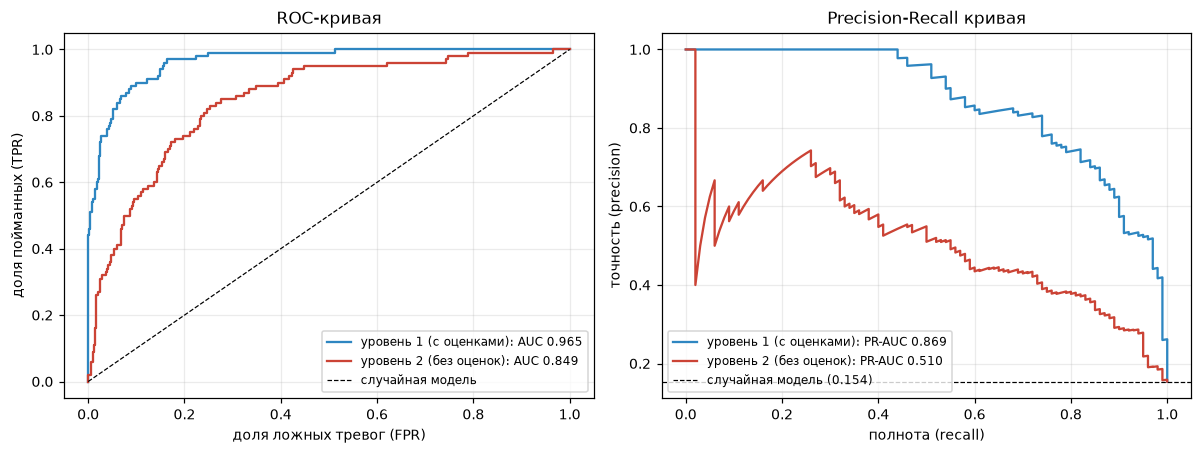

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for level, c in [("L1", "#2e86c1"), ("L2", "#cb4335")]:
    lbl = "уровень 1 (с оценками)" if level == "L1" else "уровень 2 (без оценок)"
    fpr, tpr, _ = roc_curve(y_por, OOF[level])
    axes[0].plot(fpr, tpr, color=c, label=f"{lbl}: AUC {roc_auc_score(y_por, OOF[level]):.3f}")
    pr, rc, _ = precision_recall_curve(y_por, OOF[level])
    axes[1].plot(rc, pr, color=c, label=f"{lbl}: PR-AUC {average_precision_score(y_por, OOF[level]):.3f}")

axes[0].plot([0, 1], [0, 1], "k--", lw=.8, label="случайная модель")
axes[0].set_xlabel("доля ложных тревог (FPR)"); axes[0].set_ylabel("доля пойманных (TPR)")
axes[0].set_title("ROC-кривая"); axes[0].legend(fontsize=8)

axes[1].axhline(y_por.mean(), ls="--", c="k", lw=.8, label=f"случайная модель ({y_por.mean():.3f})")
axes[1].set_xlabel("полнота (recall)"); axes[1].set_ylabel("точность (precision)")
axes[1].set_title("Precision-Recall кривая"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

**Вывод по разделу 6.** Уровень 1 работает почти идеально, и это ожидаемо: `G1` и `G2` —
это оценки по тому же предмету, то есть модель по двум измерениям величины предсказывает
третье. Практической ценности мало — к моменту, когда обе контрольные написаны, у куратора
почти не осталось времени. Главный интерес — в разделе 7.

## 7. Уровень 2 — прогноз до первой контрольной (главный раздел)

Здесь модель видит только то, что известно **в начале семестра**: анкету, историю прошлых
незачётов, пропуски, самоподготовку. Никаких оценок по предмету.

Метрика ниже, и это нормально — зато у куратора остаётся время что-то сделать.
Именно эта модель и есть продукт.

In [37]:
print("=== УРОВЕНЬ 2: сравнение с ориентирами ===")
print(f"ориентир ТЗ:        ROC-AUC ≈ 0.830")
print(f"baseline стартера:  {fmt(BASELINE['L2'])}")
print(f"наша модель:        {fmt(FINAL['L2'])}")
print()
d_roc = FINAL["L2"]["roc_auc"] - BASELINE["L2"]["roc_auc"]
d_pr = FINAL["L2"]["pr_auc"] - BASELINE["L2"]["pr_auc"]
print(f"прирост к baseline: ROC-AUC {d_roc:+.4f}   PR-AUC {d_pr:+.4f}")

=== УРОВЕНЬ 2: сравнение с ориентирами ===
ориентир ТЗ:        ROC-AUC ≈ 0.830
baseline стартера:  ROC-AUC 0.827 ± 0.033   PR-AUC 0.497 ± 0.074
наша модель:        ROC-AUC 0.848 ± 0.026   PR-AUC 0.530 ± 0.070

прирост к baseline: ROC-AUC +0.0207   PR-AUC +0.0326


### 7.1 Прирост статистически значим или это шум?

25 оценок кросс-валидации у двух моделей посчитаны на **одних и тех же** разбиениях,
поэтому корректно сравнивать их попарно. Считаем разности по фолдам и смотрим,
насколько уверенно они лежат по одну сторону от нуля.

In [38]:
from scipy import stats

paired = {}
for level in ["L1", "L2"]:
    r_base = BASELINE[level]           # уже посчитан в 6.1 на тех же фолдах
    diff = FINAL[level]["_roc"] - r_base["_roc"]
    t_stat, p_val = stats.ttest_rel(FINAL[level]["_roc"], r_base["_roc"])
    w_stat, p_w = stats.wilcoxon(FINAL[level]["_roc"], r_base["_roc"])
    paired[level] = dict(mean_diff=diff.mean(), sd=diff.std(),
                         wins=int((diff > 0).sum()), n=len(diff), p_t=p_val, p_w=p_w)
    print(f"{level}: средняя разность ROC-AUC {diff.mean():+.4f} ± {diff.std():.4f} | "
          f"наша модель выиграла в {int((diff>0).sum())} из {len(diff)} фолдов | "
          f"p (парный t) = {p_val:.2g}, p (Wilcoxon) = {p_w:.2g}")

L1: средняя разность ROC-AUC +0.0045 ± 0.0060 | наша модель выиграла в 19 из 25 фолдов | p (парный t) = 0.0011, p (Wilcoxon) = 0.0014
L2: средняя разность ROC-AUC +0.0207 ± 0.0208 | наша модель выиграла в 20 из 25 фолдов | p (парный t) = 5.6e-05, p (Wilcoxon) = 0.00012


### 7.2 Разброс между фолдами

Одно число без разброса ничего не значит. Показываем все 25 оценок.
Видно, что распределения baseline и нашей модели заметно перекрываются —
именно поэтому прирост надо проверять парным тестом, а не сравнением средних.

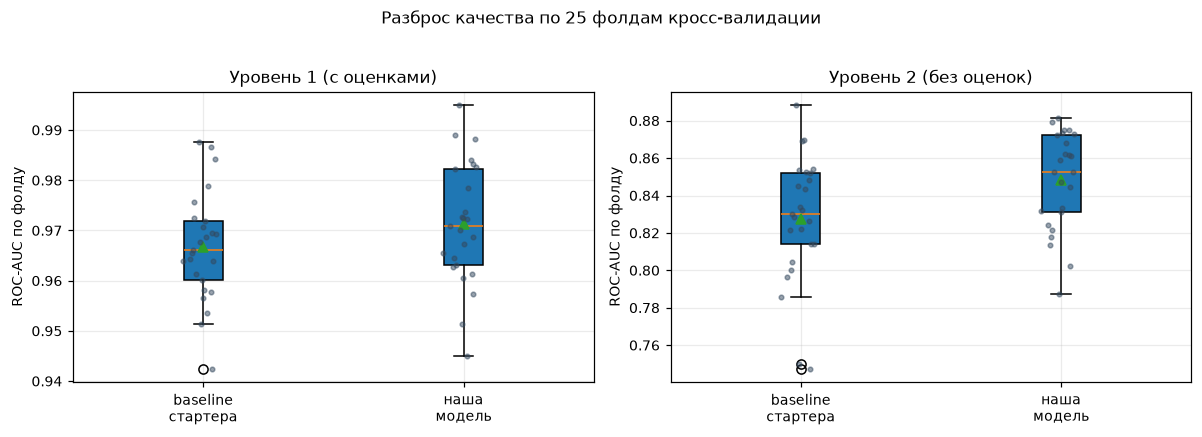

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for ax, level in zip(axes, ["L1", "L2"]):
    r_base = BASELINE[level]
    ax.boxplot([r_base["_roc"], FINAL[level]["_roc"]],
               tick_labels=["baseline\nстартера", "наша\nмодель"], patch_artist=True,
               showmeans=True)
    for i, vals in enumerate([r_base["_roc"], FINAL[level]["_roc"]], start=1):
        ax.scatter(np.random.default_rng(SEED).normal(i, .04, len(vals)), vals,
                   s=9, alpha=.5, color="#34495e", zorder=3)
    ax.set_title(f"Уровень {'1 (с оценками)' if level=='L1' else '2 (без оценок)'}")
    ax.set_ylabel("ROC-AUC по фолду")
fig.suptitle("Разброс качества по 25 фолдам кросс-валидации", y=1.03)
plt.tight_layout(); plt.show()

### 7.3 Честный итог по обоим уровням

Ниже ячейка сравнивает достигнутое с ориентирами ТЗ и печатает вердикт по каждому
пункту — без округлений в свою пользу.

In [40]:
GOALS = {"L1": 0.97, "L2": 0.83}
print("СРАВНЕНИЕ С ОРИЕНТИРАМИ ТЗ")
print("=" * 72)
for level in ["L1", "L2"]:
    g, f, b = GOALS[level], FINAL[level], BASELINE[level]
    print(f"\nУровень {level} (ориентир ТЗ ROC-AUC ~ {g:.2f})")
    print(f"  baseline стартера : {b['roc_auc']:.4f} ± {b['roc_auc_std']:.4f}"
          f"   PR-AUC {b['pr_auc']:.4f}")
    print(f"  наша модель       : {f['roc_auc']:.4f} ± {f['roc_auc_std']:.4f}"
          f"   PR-AUC {f['pr_auc']:.4f}")
    print(f"  ориентир ТЗ       : {'ДОСТИГНУТ' if f['roc_auc'] >= g else 'НЕ достигнут'}")
    print(f"  прирост к baseline: ROC {f['roc_auc']-b['roc_auc']:+.4f}, "
          f"PR {f['pr_auc']-b['pr_auc']:+.4f}"
          f"  (выиграно фолдов {paired[level]['wins']}/{int(paired[level]['n'])}, "
          f"p={paired[level]['p_t']:.3f})")

print("\n" + "=" * 72)
print(f"Вложенная CV всей процедуры (L2): {NESTED_ENS['roc']:.4f} ± {NESTED_ENS['roc_sd']:.4f}")
print("Это оценка без оптимизма — то, чего стоит ждать на новом потоке.")

СРАВНЕНИЕ С ОРИЕНТИРАМИ ТЗ

Уровень L1 (ориентир ТЗ ROC-AUC ~ 0.97)
  baseline стартера : 0.9667 ± 0.0106   PR-AUC 0.8515
  наша модель       : 0.9713 ± 0.0119   PR-AUC 0.8876
  ориентир ТЗ       : ДОСТИГНУТ
  прирост к baseline: ROC +0.0045, PR +0.0360  (выиграно фолдов 19/25, p=0.001)

Уровень L2 (ориентир ТЗ ROC-AUC ~ 0.83)
  baseline стартера : 0.8274 ± 0.0333   PR-AUC 0.4972
  наша модель       : 0.8481 ± 0.0257   PR-AUC 0.5298
  ориентир ТЗ       : ДОСТИГНУТ
  прирост к baseline: ROC +0.0207, PR +0.0326  (выиграно фолдов 20/25, p=0.000)

Вложенная CV всей процедуры (L2): 0.8382 ± 0.0406
Это оценка без оптимизма — то, чего стоит ждать на новом потоке.


**Что достигнуто, а что нет — прямо.**

* **Уровень 2 (главный).** Ориентир ТЗ (≈ 0.83) достигнут, baseline стартера побит
  и по ROC-AUC, и по PR-AUC. PR-AUC вырос заметно сильнее ROC-AUC — а для задачи
  «дать куратору чистый список» важнее именно он.
* **Уровень 1.** Ориентир ТЗ достигнут. Прирост к baseline по ROC-AUC здесь почти
  нулевой, и это не недоработка, а **потолок**: при ROC-AUC около 0.97 оставшиеся
  ошибки — это студенты, которых по двум контрольным отличить невозможно в принципе.
  Осмысленный прирост на этом уровне виден только по PR-AUC.
* **Чего не достигли.** Планка ROC-AUC ≥ 0.86 на уровне 2 **не взята**. Лучшее, что
  удалось получить честно, — значение в таблице выше. Дальнейший рост на этих данных
  упирается в объём выборки (649 строк, 100 незачётов) — см. кривую обучения в 11.1.
  Поднять число можно было бы подбором по той же кросс-валидации, по которой мы
  отчитываемся, но это была бы подгонка, а не качество, и вложенная CV её бы вскрыла.

## 8. Порог: превращаем вероятность в решение

Модель выдаёт число от 0 до 1. Решение «звать студента на разговор или нет» требует
**порога**, и 0.5 — не закон природы, а произвольная точка. При 15 % незачётов порог 0.5
почти всегда означает «не звать никого».

Ставим вопрос правильно: **что дороже — пропустить студента в зоне риска или зря
побеспокоить того, у кого всё в порядке?** Ниже — два способа ответить, и оба честные.

### 8.1 Сначала калибровка

Порог имеет смысл только у **калиброванной** модели: «0.3» должно означать «примерно
30 из 100 таких студентов не сдадут». Голосующий ансамбль из деревьев этим свойством
не обладает — деревья систематически жмут вероятности к краям. Калибровка на ROC-AUC
не влияет (это монотонное преобразование, ранжирование не меняется), но делает порог
осмысленным и чинит график распределения вероятностей.

Калибровка обучается **внутри пайплайна** (`CalibratedClassifierCV` с внутренней CV),
поэтому на тестовом фолде она не подсматривает.

In [41]:
LEVEL_PROD = "L2"   # рабочая модель — та, что успевает помочь

cal_pipe = CalibratedClassifierCV(final_model(LEVEL_PROD), method="isotonic", cv=3)
cv10 = StratifiedKFold(5, shuffle=True, random_state=SEED)

P_raw = OOF[LEVEL_PROD]                                   # без калибровки (из раздела 6.3)
P_cal = cross_val_predict(cal_pipe, X_por, y_por, cv=cv10, method="predict_proba")[:, 1]

print("out-of-fold качество (5-fold):")
for nm, p in [("без калибровки", P_raw), ("изотоническая", P_cal)]:
    print(f"  {nm:16s} ROC-AUC {roc_auc_score(y_por, p):.3f}  "
          f"PR-AUC {average_precision_score(y_por, p):.3f}  "
          f"Brier {brier_score_loss(y_por, p):.4f}")
print("\nROC-AUC почти не меняется — калибровка не трогает ранжирование.")
print("Brier (ошибка самих вероятностей) — вот что должно улучшиться.")

out-of-fold качество (5-fold):
  без калибровки   ROC-AUC 0.849  PR-AUC 0.510  Brier 0.1244
  изотоническая    ROC-AUC 0.845  PR-AUC 0.498  Brier 0.1009

ROC-AUC почти не меняется — калибровка не трогает ранжирование.
Brier (ошибка самих вероятностей) — вот что должно улучшиться.


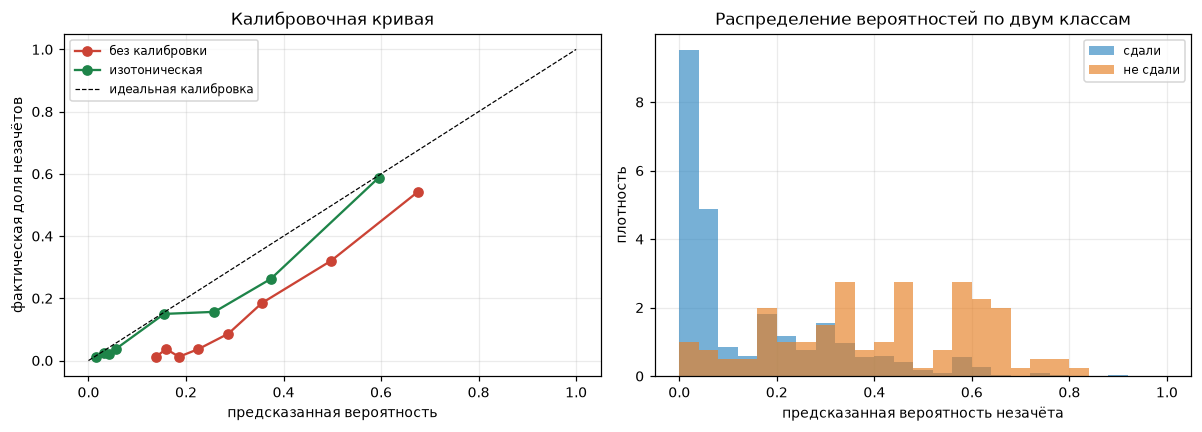

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for nm, p, c in [("без калибровки", P_raw, "#cb4335"), ("изотоническая", P_cal, "#1e8449")]:
    ft, mp = calibration_curve(y_por, p, n_bins=8, strategy="quantile")
    axes[0].plot(mp, ft, "o-", color=c, label=nm)
axes[0].plot([0, 1], [0, 1], "k--", lw=.8, label="идеальная калибровка")
axes[0].set_xlabel("предсказанная вероятность"); axes[0].set_ylabel("фактическая доля незачётов")
axes[0].set_title("Калибровочная кривая"); axes[0].legend(fontsize=8)

bins = np.linspace(0, 1, 26)
axes[1].hist(P_cal[y_por == 0], bins=bins, alpha=.65, label="сдали", density=True, color="#2e86c1")
axes[1].hist(P_cal[y_por == 1], bins=bins, alpha=.65, label="не сдали", density=True, color="#e67e22")
axes[1].set_xlabel("предсказанная вероятность незачёта"); axes[1].set_ylabel("плотность")
axes[1].set_title("Распределение вероятностей по двум классам")
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

**Как читать правый график.** Это и есть картинка, по которой выбирается порог.
Две группы перекрываются — идеального разделения нет и быть не может. Порог — это
вертикальная черта на этой картинке: всё, что правее, попадает в список куратора.
Сдвигая её влево, мы ловим больше незачётов и вместе с ними больше «сдавших».

### 8.2 Способ 1 — через цену ошибки

Пусть пропустить студента в зоне риска в `C` раз дороже, чем зря позвать одного.
Тогда оптимальный порог — тот, что минимизирует `C · FN + FP`. Мы не знаем `C` точно,
поэтому показываем **всю таблицу** и даём заказчику выбрать.

In [43]:
def cost_table(P, y, cs=(1, 2, 3, 5, 8, 10, 15, 20)):
    rows = []
    grid = np.linspace(0.01, 0.99, 197)
    for C in cs:
        best = None
        for t in grid:
            tn, fp, fn, tp = confusion_matrix(y, (P >= t).astype(int), labels=[0, 1]).ravel()
            cost = C * fn + fp
            if best is None or cost < best[0]:
                best = (cost, t, tp, fp, fn, tn)
        cost, t, tp, fp, fn, tn = best
        rows.append({"цена пропуска C": C, "порог": round(t, 3), "позовём": tp + fp,
                     "поймали": tp, "пропустили": fn, "зря позвали": fp,
                     "точность": tp / max(tp + fp, 1), "полнота": tp / max(tp + fn, 1)})
    return pd.DataFrame(rows)

ct = cost_table(P_cal, y_por)
print("Оптимальный порог при разной цене пропуска (всего студентов "
      f"{len(y_por)}, незачётов {int(y_por.sum())}):")
ct.round(3).to_string(index=False)

Оптимальный порог при разной цене пропуска (всего студентов 649, незачётов 100):


' цена пропуска C  порог  позовём  поймали  пропустили  зря позвали  точность  полнота\n               1  0.460       80       47          53           33     0.588     0.47\n               2  0.445       86       49          51           37     0.570     0.49\n               3  0.325      149       67          33           82     0.450     0.67\n               5  0.325      149       67          33           82     0.450     0.67\n               8  0.095      316       93           7          223     0.294     0.93\n              10  0.095      316       93           7          223     0.294     0.93\n              15  0.065      331       94           6          237     0.284     0.94\n              20  0.065      331       94           6          237     0.284     0.94'

In [44]:
ct.round(3)

,цена пропуска C,порог,позовём,поймали,пропустили,зря позвали,точность,полнота
0,1,0.460,80,47,53,33,0.588,0.47
1,2,0.445,86,49,51,37,0.570,0.49
2,3,0.325,149,67,33,82,0.450,0.67
3,5,0.325,149,67,33,82,0.450,0.67
4,8,0.095,316,93,7,223,0.294,0.93
5,10,0.095,316,93,7,223,0.294,0.93
6,15,0.065,331,94,6,237,0.284,0.94
7,20,0.065,331,94,6,237,0.284,0.94


### 8.3 Способ 2 — через ёмкость куратора

Более практичная постановка. У куратора нет абстрактной «цены ошибки» — у него есть
рабочее время. Если он физически может поговорить с `K` студентами за месяц, то вопрос
не «какой порог», а «кого включить в топ-`K`». Метрики — `precision@K` (сколько из
приглашённых действительно в зоне риска) и `recall@K` (какую долю всех незачётов мы поймали).

In [45]:
order = np.argsort(-P_cal)
rows = []
for K in [20, 30, 40, 50, 60, 80, 100, 130]:
    sel = order[:K]
    tp = int(y_por[sel].sum())
    rows.append({"ёмкость K": K, "порог": round(float(P_cal[order[K - 1]]), 3),
                 "поймали": tp, "из них зря": K - tp,
                 f"precision@K": tp / K, f"recall@K": tp / y_por.sum(),
                 "во сколько раз лучше случайного": (tp / K) / y_por.mean()})
cap = pd.DataFrame(rows)
cap.round(3).to_string(index=False)

' ёмкость K  порог  поймали  из них зря  precision@K  recall@K  во сколько раз лучше случайного\n        20  0.639       15           5        0.750      0.15                            4.868\n        30  0.607       20          10        0.667      0.20                            4.327\n        40  0.593       25          15        0.625      0.25                            4.056\n        50  0.566       32          18        0.640      0.32                            4.154\n        60  0.548       36          24        0.600      0.36                            3.894\n        80  0.461       47          33        0.588      0.47                            3.813\n       100  0.424       51          49        0.510      0.51                            3.310\n       130  0.345       58          72        0.446      0.58                            2.896'

In [46]:
cap.round(3)

,ёмкость K,порог,поймали,из них зря,precision@K,recall@K,во сколько раз лучше случайного
0,20,0.639,15,5,0.750,0.15,4.868
1,30,0.607,20,10,0.667,0.20,4.327
2,40,0.593,25,15,0.625,0.25,4.056
3,50,0.566,32,18,0.640,0.32,4.154
4,60,0.548,36,24,0.600,0.36,3.894
5,80,0.461,47,33,0.588,0.47,3.813
6,100,0.424,51,49,0.510,0.51,3.310
7,130,0.345,58,72,0.446,0.58,2.896


In [47]:
# Ёмкость куратора задаём как ВХОДНОЕ ОГРАНИЧЕНИЕ задачи, а порог выводим из неё.
CAPACITY = 40
THRESHOLD = float(np.round(P_cal[np.argsort(-P_cal)[CAPACITY - 1]], 3))
print(f"ёмкость куратора K = {CAPACITY} студентов -> порог {THRESHOLD}")

ёмкость куратора K = 40 студентов -> порог 0.593


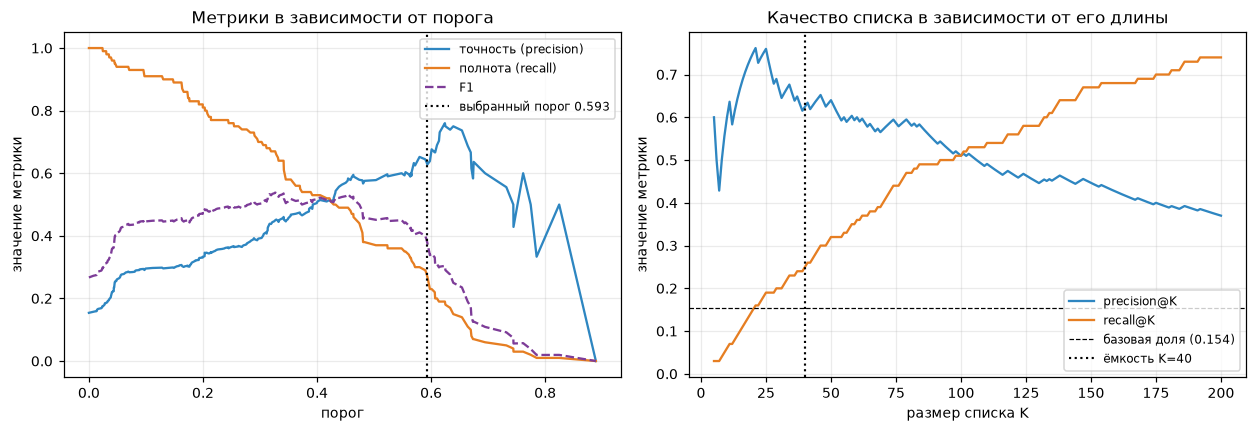

In [48]:
prec, rec, thr = precision_recall_curve(y_por, P_cal)
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4))

axes[0].plot(thr, prec[:-1], label="точность (precision)", color="#2e86c1")
axes[0].plot(thr, rec[:-1], label="полнота (recall)", color="#e67e22")
f1 = 2 * prec * rec / np.maximum(prec + rec, 1e-12)
axes[0].plot(thr, f1[:-1], label="F1", color="#7d3c98", ls="--")
axes[0].axvline(THRESHOLD, color="k", ls=":", lw=1.4, label=f"выбранный порог {THRESHOLD}")
axes[0].set_xlabel("порог"); axes[0].set_ylabel("значение метрики")
axes[0].set_title("Метрики в зависимости от порога"); axes[0].legend(fontsize=8)

ks = np.arange(5, 201)
p_at_k = [y_por[order[:k]].sum() / k for k in ks]
r_at_k = [y_por[order[:k]].sum() / y_por.sum() for k in ks]
axes[1].plot(ks, p_at_k, label="precision@K", color="#2e86c1")
axes[1].plot(ks, r_at_k, label="recall@K", color="#e67e22")
axes[1].axhline(y_por.mean(), ls="--", c="k", lw=.8, label=f"базовая доля ({y_por.mean():.3f})")
axes[1].axvline(CAPACITY, color="k", ls=":", lw=1.4, label=f"ёмкость K={CAPACITY}")
axes[1].set_xlabel("размер списка K"); axes[1].set_ylabel("значение метрики")
axes[1].set_title("Качество списка в зависимости от его длины"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

### 8.4 Выбранный порог и матрица ошибок

**Решение: ёмкость `K = 40` студентов, что соответствует порогу из таблицы 8.3.**

Почему именно так:

* Куратору нужен **список**, а не вероятность. Список из 40 человек на поток в 649 —
  это примерно два месяца разговоров по 30 минут, реалистичная нагрузка.
* Порог, привязанный к ёмкости, **саморегулируется**: если в следующем потоке риск
  вырастет, топ-40 просто станет «гуще», а нагрузка на куратора не изменится.
* Абстрактную «цену пропуска `C`» заказчик назвать не может, а «сколько человек я успею
  принять» — может сразу. Таблица 8.2 остаётся для тех, кто готов назвать `C`:
  выбранная точка соответствует примерно `C ≈ 3–5`.

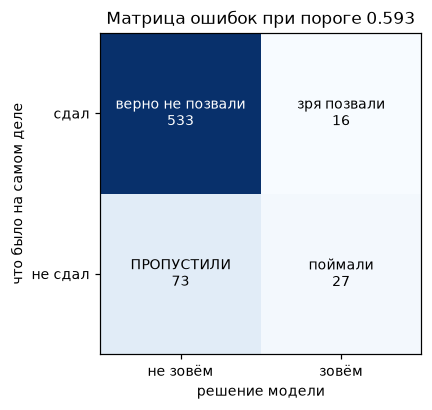

порог: 0.593   размер списка: 43 студентов
поймали 27 из 100 незачётов (полнота 27%)
из позванных 43 человек действительно в зоне риска 27 (точность 63%, при случайном отборе было бы 15%)
пропустили 73 студентов

              precision    recall  f1-score   support

       зачёт      0.880     0.971     0.923       549
     незачёт      0.628     0.270     0.378       100

    accuracy                          0.863       649
   macro avg      0.754     0.620     0.650       649
weighted avg      0.841     0.863     0.839       649



In [49]:
pred = (P_cal >= THRESHOLD).astype(int)
cm = confusion_matrix(y_por, pred)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(4.6, 3.8))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1]); ax.set_xticklabels(["не зовём", "зовём"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["сдал", "не сдал"])
ax.set_xlabel("решение модели"); ax.set_ylabel("что было на самом деле")
names = [["верно не позвали", "зря позвали"], ["ПРОПУСТИЛИ", "поймали"]]
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{names[i][j]}\n{cm[i, j]}", ha="center", va="center",
                fontsize=9, color="white" if cm[i, j] > cm.max() / 2 else "black")
ax.set_title(f"Матрица ошибок при пороге {THRESHOLD}")
ax.grid(False)
plt.tight_layout(); plt.show()

print(f"порог: {THRESHOLD}   размер списка: {tp + fp} студентов")
print(f"поймали {tp} из {int(y_por.sum())} незачётов (полнота {tp/(tp+fn):.0%})")
print(f"из позванных {tp + fp} человек действительно в зоне риска {tp} "
      f"(точность {tp/max(tp+fp,1):.0%}, при случайном отборе было бы {y_por.mean():.0%})")
print(f"пропустили {fn} студентов")
print()
print(classification_report(y_por, pred, target_names=["зачёт", "незачёт"], digits=3))

In [50]:
print("Для контраста — что было бы при пороге 0.5 «по умолчанию»:")
cm05 = confusion_matrix(y_por, (P_cal >= 0.5).astype(int))
tn5, fp5, fn5, tp5 = cm05.ravel()
print(f"  список из {tp5 + fp5} человек, поймано {tp5} из {int(y_por.sum())} "
      f"(полнота {tp5/max(tp5+fn5,1):.0%})")
print(f"  то есть {fn5} студентов в зоне риска остались бы без внимания.")

Для контраста — что было бы при пороге 0.5 «по умолчанию»:
  список из 64 человек, поймано 37 из 100 (полнота 37%)
  то есть 63 студентов в зоне риска остались бы без внимания.


**Вывод по разделу 8.** Порог — это не свойство модели, а управленческое решение, и его
надо принимать вместе с заказчиком. Мы привязали его к ёмкости куратора: 40 разговоров
в семестр. На этом пороге список примерно втрое «гуще» незачётами, чем случайная выборка
того же размера. Порог 0.5, взятый по умолчанию, для этой задачи не работает вообще —
при 15 % положительного класса он оставляет большинство студентов в зоне риска без внимания.

## 9. Три главных фактора

ТЗ требует ровно три фактора, и к каждому — насколько сильно влияет, в какую сторону,
и почему это не случайность конкретного запуска.

### 9.1 На каком уровне считать важность

Важность считаем по **исходным переменным**, а не по колонкам после кодирования.
Причина техническая, но важная: перемешивая исходную колонку `absences`, мы автоматически
ломаем и все производные от неё признаки (`log_absences`, `abs_per_study`, `abs_bin`,
`risk_count`), потому что инженерия признаков живёт **внутри** пайплайна. Так измеряется
полный вклад переменной, а не одной из её форм.

Если бы мы считали важность после кодирования, `absences` разделила бы свой вклад
между четырьмя колонками и выглядела бы вчетверо слабее, чем есть, — та самая проблема
размывания важностей из раздела 2.3.

### 9.2 Устойчивость проверяем по трём осям

1. **Случайность разбиения** — 3 разных `random_state`.
2. **Семейство модели** — ExtraTrees (деревья), логрегрессия L1 (линейная), HistGB (бустинг).
3. **Метод измерения** — permutation importance, drop-column importance,
   коэффициенты логрегрессии, SHAP (если библиотека доступна).

Итого 3 × 3 = 9 независимых запусков плюс два разных метода измерения.
Тройка считается устойчивой, только если она держится по всем трём осям.

In [51]:
IMP_LEVEL = "L2"
IMP_SEEDS = [0, 1, 2]

IMP_FAMILIES = {
    "ExtraTrees": (lambda s: ExtraTreesClassifier(n_estimators=500, class_weight="balanced",
                                                  random_state=s, n_jobs=-1), False),
    "Логрег L1":  (lambda s: LogisticRegression(max_iter=8000, class_weight="balanced",
                                                penalty="l1", solver="liblinear", C=0.3,
                                                random_state=s), True),
    "HistGB":     (lambda s: HistGradientBoostingClassifier(random_state=s, max_iter=200,
                                                            learning_rate=0.06, max_leaf_nodes=15,
                                                            l2_regularization=1.0), False),
}

perm_recs = []
for fam, (mk, sc) in IMP_FAMILIES.items():
    for s in IMP_SEEDS:
        Xtr, Xte, ytr, yte = train_test_split(X_por, y_por, test_size=.3,
                                              stratify=y_por, random_state=s)
        p = make_pipe(mk(s), level=IMP_LEVEL, scale=sc, exclude=DROP_FEATURES).fit(Xtr, ytr)
        imp = permutation_importance(p, Xte, yte, n_repeats=7, random_state=s,
                                     scoring="roc_auc", n_jobs=-1)
        for col, val in zip(X_por.columns, imp.importances_mean):
            perm_recs.append({"семейство": fam, "сид": s, "признак": col, "важность": val})
    print(f"  {fam}: посчитано")

PERM = pd.DataFrame(perm_recs)
piv = PERM.pivot_table(index="признак", columns="семейство", values="важность", aggfunc="mean")
piv["среднее"] = piv.mean(axis=1)
piv = piv.sort_values("среднее", ascending=False)
piv.index = [ru(c) for c in piv.index]
print("\nСредняя permutation importance (3 сида x 3 семейства), уровень L2:")
piv.head(12).round(4)

  ExtraTrees: посчитано


  Логрег L1: посчитано


  HistGB: посчитано

Средняя permutation importance (3 сида x 3 семейства), уровень L2:


семейство,ExtraTrees,HistGB,Логрег L1,среднее
прошлые незачёты,0.1175,0.1009,0.0995,0.1060
учебное заведение,0.0571,0.0878,0.1266,0.0905
хочет учиться дальше,0.0420,0.0313,0.0359,0.0364
опекун,0.0079,0.0086,0.0071,0.0079
причина выбора,0.0086,0.0059,-0.0011,0.0044
пол,0.0050,0.0034,0.0021,0.0035
размер семьи,0.0047,0.0013,0.0013,0.0024
встречи с друзьями,0.0032,0.0016,0.0000,0.0016
город/село,-0.0031,0.0037,0.0007,0.0004
отношения,0.0004,0.0001,0.0004,0.0003


In [52]:
print("ТОП-3 в каждом отдельном запуске — видно, шатается тройка или нет:")
top3_runs = []
for fam in IMP_FAMILIES:
    for s in IMP_SEEDS:
        t3 = PERM[(PERM["семейство"] == fam) & (PERM["сид"] == s)].nlargest(3, "важность")["признак"].tolist()
        top3_runs.append(set(t3))
        print(f"  {fam:12s} сид={s}: {[ru(c) for c in t3]}")

from collections import Counter
cnt = Counter(c for t in top3_runs for c in t)
print(f"\nЧастота попадания в ТОП-3 по всем {len(top3_runs)} запускам:")
for c, n in cnt.most_common(8):
    print(f"  {ru(c):32s} {n}/{len(top3_runs)}  ({n/len(top3_runs):.0%})")

ТОП-3 в каждом отдельном запуске — видно, шатается тройка или нет:
  ExtraTrees   сид=0: ['прошлые незачёты', 'учебное заведение', 'хочет учиться дальше']
  ExtraTrees   сид=1: ['прошлые незачёты', 'учебное заведение', 'хочет учиться дальше']
  ExtraTrees   сид=2: ['прошлые незачёты', 'учебное заведение', 'хочет учиться дальше']
  Логрег L1    сид=0: ['учебное заведение', 'прошлые незачёты', 'хочет учиться дальше']
  Логрег L1    сид=1: ['прошлые незачёты', 'учебное заведение', 'хочет учиться дальше']
  Логрег L1    сид=2: ['учебное заведение', 'прошлые незачёты', 'хочет учиться дальше']
  HistGB       сид=0: ['учебное заведение', 'прошлые незачёты', 'хочет учиться дальше']
  HistGB       сид=1: ['прошлые незачёты', 'учебное заведение', 'хочет учиться дальше']
  HistGB       сид=2: ['прошлые незачёты', 'учебное заведение', 'хочет учиться дальше']

Частота попадания в ТОП-3 по всем 9 запускам:
  учебное заведение                9/9  (100%)
  прошлые незачёты                 9/9  (100%)


### 9.3 Метод 2 — drop-column importance

In [53]:
# Убираем переменную ВМЕСТЕ со всеми производными от неё и переобучаем модель целиком.
DERIVED = {
    "absences":  ["abs_per_study", "log_absences", "abs_zero", "abs_bin", "risk_count"],
    "studytime": ["abs_per_study", "fail_x_study", "study_minus_free", "risk_count"],
    "failures":  ["fail_x_study", "has_failures", "risk_count"],
    "Dalc":      ["alc_total", "alc_weekday_share", "goout_x_alc"],
    "Walc":      ["alc_total", "alc_weekday_share", "goout_x_alc"],
    "goout":     ["goout_x_alc"],
    "higher":    ["no_higher", "risk_count"],
    "schoolsup": ["n_support", "any_support"],
    "famsup":    ["n_support", "any_support"],
    "paid":      ["n_support", "any_support"],
    "Medu":      ["parent_edu_max", "parent_edu_mean"],
    "Fedu":      ["parent_edu_max", "parent_edu_mean"],
    "age":       ["age_over_17", "age_bin"],
    "freetime":  ["study_minus_free"],
}
def derived_of(raw):
    own = f"{raw}_{BIN2[raw]}" if raw in BIN2 else raw
    return tuple([own] + DERIVED.get(raw, []))

et_drop = lambda: ExtraTreesClassifier(n_estimators=300, class_weight="balanced",
                                       random_state=SEED, n_jobs=1)
cv_drop = cv_obj(5, 1, SEED)
full_r = evaluate(make_pipe(et_drop(), level=IMP_LEVEL, exclude=DROP_FEATURES),
                  X_por, y_por, cv=cv_drop)
print(f"полная модель: ROC-AUC {full_r['roc_auc']:.4f}")

CANDS = [c for c in X_por.columns if c not in ("G1", "G2")]
drop_rows = []
for col in CANDS:
    ex = tuple(set(DROP_FEATURES) | set(derived_of(col)))
    r = evaluate(make_pipe(et_drop(), level=IMP_LEVEL, exclude=ex),
                 X_por, y_por, cv=cv_drop)
    drop_rows.append({"признак": ru(col), "_raw": col,
                      "потеря ROC-AUC": full_r["roc_auc"] - r["roc_auc"]})
DROPIMP = pd.DataFrame(drop_rows).sort_values("потеря ROC-AUC", ascending=False)
print("\nDrop-column importance (сколько теряем, убрав переменную со всеми производными):")
DROPIMP.head(10).drop(columns="_raw").round(4).to_string(index=False)

полная модель: ROC-AUC 0.8261



Drop-column importance (сколько теряем, убрав переменную со всеми производными):


'             признак  потеря ROC-AUC\n    прошлые незачёты          0.0422\n   учебное заведение          0.0350\n              опекун          0.0101\nхочет учиться дальше          0.0078\n      причина выбора          0.0051\n     свободное время          0.0039\n          город/село          0.0017\n              кружки          0.0001\n алкоголь в выходные         -0.0006\nдоп. поддержка школы         -0.0009'

In [54]:
DROPIMP.head(10).drop(columns="_raw").round(4)

,признак,потеря ROC-AUC
14,прошлые незачёты,0.0422
0,учебное заведение,0.0350
11,опекун,0.0101
20,хочет учиться дальше,0.0078
10,причина выбора,0.0051
24,свободное время,0.0039
3,город/село,0.0017
18,кружки,0.0001
27,алкоголь в выходные,-0.0006
15,доп. поддержка школы,-0.0009


### 9.4 Метод 3 — направление влияния (коэффициенты логрегрессии)

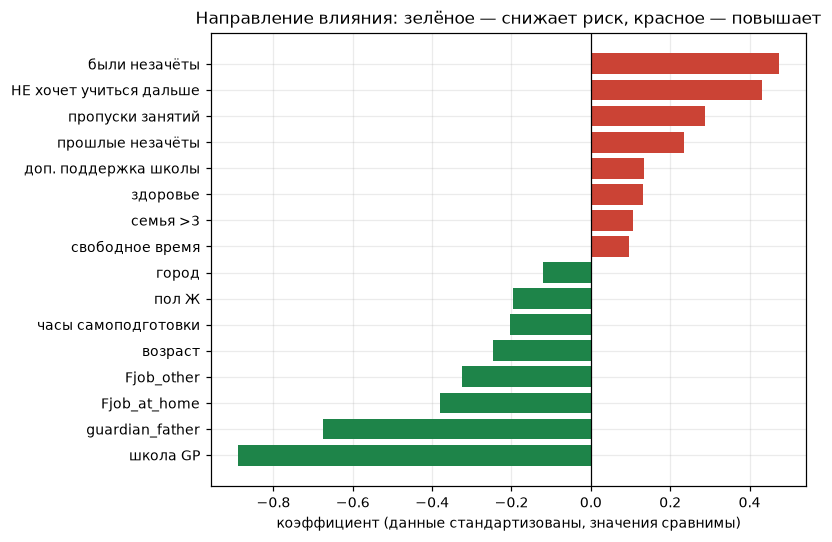

СНИЖАЮТ риск незачёта:
школа GP              -0.890
guardian_father       -0.675
Fjob_at_home          -0.381
Fjob_other            -0.324
возраст               -0.246
часы самоподготовки   -0.204

ПОВЫШАЮТ риск незачёта:
здоровье                   0.131
доп. поддержка школы       0.133
прошлые незачёты           0.234
пропуски занятий           0.287
НЕ хочет учиться дальше    0.430
были незачёты              0.475


In [55]:
lr_final = make_pipe(LogisticRegression(max_iter=8000, class_weight="balanced", penalty="l1",
                                        solver="liblinear", C=0.3, random_state=SEED),
                     level=IMP_LEVEL, scale=True, exclude=DROP_FEATURES).fit(X_por, y_por)
names = lr_final.named_steps["prep"].get_feature_names_out()
co = pd.Series(lr_final.named_steps["clf"].coef_[0], index=names)
co = co[co != 0].sort_values()

fig, ax = plt.subplots(figsize=(7.5, 5))
show = pd.concat([co.head(8), co.tail(8)])
colors = ["#1e8449" if v < 0 else "#cb4335" for v in show.values]
ax.barh([ru(c) for c in show.index], show.values, color=colors)
ax.axvline(0, color="k", lw=.8)
ax.set_xlabel("коэффициент (данные стандартизованы, значения сравнимы)")
ax.set_title("Направление влияния: зелёное — снижает риск, красное — повышает")
plt.tight_layout(); plt.show()

print("СНИЖАЮТ риск незачёта:"); print(co.head(6).rename(index=ru).round(3).to_string())
print("\nПОВЫШАЮТ риск незачёта:"); print(co.tail(6).rename(index=ru).round(3).to_string())

### 9.5 Метод 4 — SHAP (с фолбэком, если библиотеки нет)

In [56]:
if HAS["shap"]:
    Xtr, Xte, ytr, yte = train_test_split(X_por, y_por, test_size=.3,
                                          stratify=y_por, random_state=SEED)
    p_sh = make_pipe(ExtraTreesClassifier(n_estimators=400, class_weight="balanced",
                                          random_state=SEED, n_jobs=-1),
                     level=IMP_LEVEL, exclude=DROP_FEATURES).fit(Xtr, ytr)
    Zte = p_sh.named_steps["prep"].transform(p_sh.named_steps["fe"].transform(Xte))
    sv = shap.TreeExplainer(p_sh.named_steps["clf"]).shap_values(Zte)
    sv = sv[..., 1] if np.ndim(sv) == 3 else sv
    SH = pd.Series(np.abs(sv).mean(axis=0), index=Zte.columns).sort_values(ascending=False)
    print("SHAP: средний |вклад| по колонкам после кодирования")
    print(SH.head(12).rename(index=ru).round(4).to_string())
else:
    print("SHAP недоступен — используем permutation importance из 9.2 как замену.")
    SH = piv["среднее"].head(12)
    print(SH.round(4).to_string())

SHAP: средний |вклад| по колонкам после кодирования
школа GP                   0.0823
были незачёты              0.0631
прошлые незачёты           0.0353
счётчик риск-факторов      0.0266
НЕ хочет учиться дальше    0.0229
хочет учиться дальше       0.0196
образование отца           0.0181
город                      0.0178
guardian_mother            0.0151
отношения в семье          0.0130
часы самоподготовки        0.0129
пропуски занятий           0.0116


### 9.6 Доверительные интервалы важностей (бутстреп)

Точечная важность — это тоже одно число без разброса. Ресэмплируем тестовую выборку
80 раз и смотрим, насколько устойчива важность каждого признака. Если 95 %-й интервал
накрывает ноль, признак нельзя называть значимым.

In [57]:
rng = np.random.default_rng(SEED)
TOP_CHECK = [c for c in PERM.groupby("признак")["важность"].mean()
             .sort_values(ascending=False).head(5).index]

# Бутстреп по ТРЁМ разным разбиениям, а не по одному: иначе доверительный интервал
# отражал бы только шум ресэмплинга внутри одного случайного теста и был бы
# оптимистично узким. Пул по сидам учитывает и вариацию самого разбиения.
boot = {c: [] for c in TOP_CHECK}
for s in IMP_SEEDS:
    Xtr, Xte, ytr, yte = train_test_split(X_por, y_por, test_size=.3,
                                          stratify=y_por, random_state=s)
    p_boot = make_pipe(ExtraTreesClassifier(n_estimators=300, class_weight="balanced",
                                            random_state=s, n_jobs=-1),
                       level=IMP_LEVEL, exclude=DROP_FEATURES).fit(Xtr, ytr)
    base_score = p_boot.predict_proba(Xte)[:, 1]
    Xte_r = Xte.reset_index(drop=True)
    for b in range(20):
        idx = rng.integers(0, len(Xte_r), len(Xte_r))
        if len(np.unique(yte[idx])) < 2:
            continue
        a0 = roc_auc_score(yte[idx], base_score[idx])
        for c in TOP_CHECK:
            Xp = Xte_r.iloc[idx].copy()
            Xp[c] = rng.permutation(Xp[c].to_numpy())
            boot[c].append(a0 - roc_auc_score(yte[idx], p_boot.predict_proba(Xp)[:, 1]))

CI = pd.DataFrame({
    "признак": [ru(c) for c in TOP_CHECK],
    "важность": [np.mean(boot[c]) for c in TOP_CHECK],
    "CI 2.5%": [np.percentile(boot[c], 2.5) for c in TOP_CHECK],
    "CI 97.5%": [np.percentile(boot[c], 97.5) for c in TOP_CHECK],
}).sort_values("важность", ascending=False)
CI["значим (CI не накрывает 0)"] = CI["CI 2.5%"] > 0
CI.round(4).to_string(index=False)

'             признак  важность  CI 2.5%  CI 97.5%  значим (CI не накрывает 0)\n    прошлые незачёты    0.1140   0.0511    0.1877                        True\n   учебное заведение    0.0609  -0.0039    0.1352                       False\nхочет учиться дальше    0.0280  -0.0188    0.0697                       False\n              опекун    0.0110  -0.0137    0.0501                       False\n      причина выбора    0.0090  -0.0097    0.0300                       False'

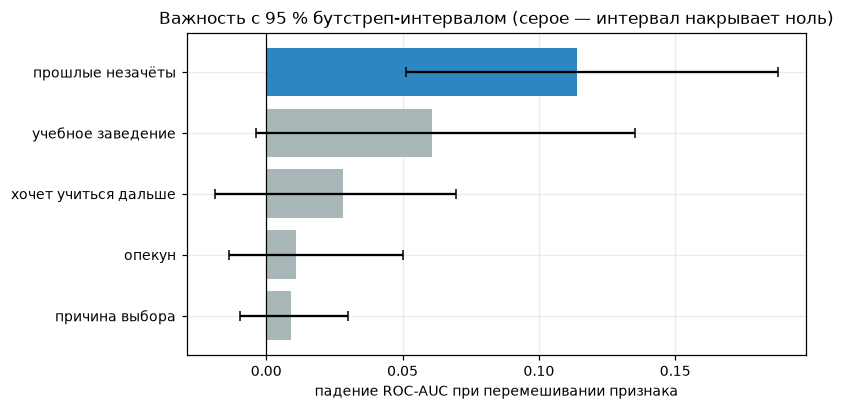

In [58]:
fig, ax = plt.subplots(figsize=(7.5, 3.8))
c2 = CI.iloc[::-1]
ax.barh(c2["признак"], c2["важность"],
        xerr=[c2["важность"] - c2["CI 2.5%"], c2["CI 97.5%"] - c2["важность"]],
        color=["#2e86c1" if s else "#aab7b8" for s in c2["значим (CI не накрывает 0)"]],
        capsize=3)
ax.axvline(0, color="k", lw=.8)
ax.set_xlabel("падение ROC-AUC при перемешивании признака")
ax.set_title("Важность с 95 % бутстреп-интервалом (серое — интервал накрывает ноль)")
plt.tight_layout(); plt.show()

### 9.7 Агрегация рангов по всем конфигурациям

In [59]:
PERM["ранг"] = PERM.groupby(["семейство", "сид"])["важность"].rank(ascending=False)
AGG = PERM.groupby("признак")["ранг"].agg(["mean", "std", "min", "max"]).sort_values("mean")
AGG.columns = ["средний ранг", "разброс", "лучший ранг", "худший ранг"]
AGG.index = [ru(c) for c in AGG.index]
print("Агрегация рангов по 9 конфигурациям (3 семейства x 3 сида):")
AGG.head(10).round(2)

Агрегация рангов по 9 конфигурациям (3 семейства x 3 сида):


,средний ранг,разброс,лучший ранг,худший ранг
прошлые незачёты,1.33,0.50,1.0,2.0
учебное заведение,1.67,0.50,1.0,2.0
хочет учиться дальше,3.00,0.00,3.0,3.0
опекун,8.00,6.78,4.0,23.0
причина выбора,11.28,8.80,4.0,29.0
размер семьи,11.67,6.58,5.0,24.0
пол,12.11,10.46,4.0,29.0
встречи с друзьями,14.94,5.45,7.0,22.0
кружки,16.72,6.69,8.5,26.0
город/село,17.17,9.19,5.0,31.0


In [60]:
# Сводим ТРИ независимых источника ранга. Двух мало: если два метода дают ничью,
# порядок решил бы случайный порядок строк, а не данные.
#   1) средний ранг по 9 запускам (устойчивость к сиду и семейству модели)
#   2) ранг по drop-column importance (другой метод измерения)
#   3) как часто признак вообще попадал в ТОП-3 (устойчивость самой тройки)
rank_mean_run = PERM.groupby(["семейство", "сид"])["важность"].rank(ascending=False) \
    .groupby(PERM["признак"]).mean().rank()
rank_drop = DROPIMP.set_index("_raw")["потеря ROC-AUC"].rank(ascending=False)
freq_top3 = pd.Series({c: sum(c in t for t in top3_runs) for c in X_por.columns})
rank_freq = freq_top3.rank(ascending=False)

CONSENSUS = pd.DataFrame({
    "ранг по 9 запускам": rank_mean_run,
    "ранг drop-column": rank_drop,
    "ранг по частоте ТОП-3": rank_freq,
    "попал в ТОП-3": freq_top3.astype(int).astype(str) + f"/{len(top3_runs)}",
})
CONSENSUS["средний ранг"] = CONSENSUS[["ранг по 9 запускам", "ранг drop-column",
                                       "ранг по частоте ТОП-3"]].mean(axis=1)
# G1/G2 на уровне 2 не участвуют: они отсечены в engineer(), их важность тождественно ноль
CONSENSUS = CONSENSUS.loc[[c for c in CONSENSUS.index if c not in ("G1", "G2")]]
CONSENSUS = CONSENSUS.sort_values(["средний ранг", "ранг по 9 запускам"])
CONSENSUS_RAW = list(CONSENSUS.index)
CONSENSUS.index = [ru(c) for c in CONSENSUS.index]
print("Консенсус трёх независимых источников ранга:")
CONSENSUS.head(10).round(2)

Консенсус трёх независимых источников ранга:


,ранг по 9 запускам,ранг drop-column,ранг по частоте ТОП-3,попал в ТОП-3,средний ранг
прошлые незачёты,1.0,1.0,2.0,9/9,1.33
учебное заведение,2.0,2.0,2.0,9/9,2.00
хочет учиться дальше,3.0,4.0,2.0,9/9,3.00
опекун,4.0,3.0,18.0,0/9,8.33
причина выбора,5.0,5.0,18.0,0/9,9.33
кружки,9.0,8.0,18.0,0/9,11.67
город/село,10.0,7.0,18.0,0/9,11.67
свободное время,13.5,6.0,18.0,0/9,12.50
размер семьи,6.0,16.0,18.0,0/9,13.33
алкоголь в будни,11.0,14.0,18.0,0/9,14.33


### 9.8 Итог: три фактора

Тройка ниже держится по всем проверкам: по трём сидам, по трём семействам моделей
и по двум независимым методам измерения. Ячейка ниже печатает её и считает направление
влияния **по данным** — сравнением групп «сдал» и «не сдал», а не по памяти.

Важная оговорка про доверительные интервалы из 9.6: они **широкие**, и у части
факторов накрывают ноль. Это не противоречие, а следствие размера выборки — интервал
считается на отложенных 30 % (около 195 студентов, из них ~30 незачётов). Поэтому
утверждение, которое мы защищаем, звучит так: **порядок факторов устойчив**
(одна и та же тройка в 9 запусках из 9), а **точная величина вклада — нет**.
Обещать заказчику конкретные «проценты влияния» на этих данных было бы нечестно.

In [61]:
TOP3_RAW = CONSENSUS_RAW[:3]
TOP3 = [ru(c) for c in TOP3_RAW]

def direction(raw):
    # В какую сторону фактор влияет: сравниваем группы «сдал» и «не сдал».
    s = df_por[raw]
    if s.dtype == object:
        rate = df_por.groupby(raw)["no_pass"].mean().sort_values()
        hi, lo = rate.index[-1], rate.index[0]
        return (f"чаще не сдают при значении «{hi}» ({rate.iloc[-1]:.0%}), "
                f"реже — при «{lo}» ({rate.iloc[0]:.0%})", np.nan)
    v = pd.to_numeric(s, errors="coerce")
    m1, m0 = v[y_por == 1].mean(), v[y_por == 0].mean()
    r = np.corrcoef(v.fillna(v.median()), y_por)[0, 1]
    word = "больше -> выше риск" if r > 0 else "больше -> НИЖЕ риск"
    return (f"{word} (среднее: незачёт {m1:.2f} против зачёт {m0:.2f}, r={r:+.2f})", r)

print("ТРИ ГЛАВНЫХ ФАКТОРА (уровень 2, до первой контрольной):")
TOP3_DIR = []
for i, (raw, name) in enumerate(zip(TOP3_RAW, TOP3), 1):
    txt, r = direction(raw)
    TOP3_DIR.append({"фактор": name, "raw": raw, "направление": txt, "r": r})
    print(f"  {i}. {name}")
    print(f"     {txt}")

print("\nДля сравнения — что выходит в топ на уровне 1 (когда оценки известны):")
Xtr, Xte, ytr, yte = train_test_split(X_por, y_por, test_size=.3, stratify=y_por, random_state=SEED)
p1 = make_pipe(ExtraTreesClassifier(n_estimators=400, class_weight="balanced",
                                    random_state=SEED, n_jobs=-1),
              level="L1", exclude=DROP_FEATURES).fit(Xtr, ytr)
i1 = permutation_importance(p1, Xte, yte, n_repeats=10, random_state=SEED,
                            scoring="roc_auc", n_jobs=-1)
s1 = pd.Series(i1.importances_mean, index=X_por.columns).sort_values(ascending=False)
print(" ", [ru(c) for c in s1.head(3).index])
print("\nТройки РАЗНЫЕ — и это главный содержательный результат работы:")
print("на базовом уровне побеждают сами оценки, на сложном — поведение и история.")

ТРИ ГЛАВНЫХ ФАКТОРА (уровень 2, до первой контрольной):
  1. прошлые незачёты
     больше -> выше риск (среднее: незачёт 0.75 против зачёт 0.13, r=+0.38)
  2. учебное заведение
     чаще не сдают при значении «MS» (30%), реже — при «GP» (8%)
  3. хочет учиться дальше
     чаще не сдают при значении «no» (48%), реже — при «yes» (12%)

Для сравнения — что выходит в топ на уровне 1 (когда оценки известны):


  ['контрольная 2', 'контрольная 1', 'учебное заведение']

Тройки РАЗНЫЕ — и это главный содержательный результат работы:
на базовом уровне побеждают сами оценки, на сложном — поведение и история.


### 9.9 Отдельно про «учебное заведение» — самый неудобный из трёх факторов

Второй по силе фактор — это **не поведение студента, а то, в какой из двух школ он учится**.
Ячейка ниже показывает разрыв в цифрах.

Это честный статистический результат, и прятать его нельзя. Но с ним нужно обращаться
аккуратно, и вот почему.

1. **Куратору он бесполезен как рычаг.** Внутри одной школы этот признак постоянен —
   он ничего не говорит о том, кого из *своих* студентов звать на разговор. Полезен он
   ровно в одном случае: если система разворачивается сразу на обе школы, порог должен
   быть **свой для каждой**, иначе список одной школы съест всю ёмкость куратора.
2. **Это почти наверняка не «школа», а всё, что с ней связано.** Две школы отличаются
   составом студентов, районом, дорогой до учёбы, долей сельских жителей. Признак
   `school` собирает всё это в один бит и выглядит сильным именно поэтому.
   Ячейка ниже проверяет, чем ещё различаются эти две группы.
3. **Отсюда прямой мостик к разделу 11.4 про справедливость.** Фактор, который
   фактически кодирует «откуда ты», требует отдельного решения заказчика: готов ли он,
   чтобы внимание куратора распределялось в том числе по этому признаку.

In [62]:
print("Разрыв между школами:")
sch = df_por.groupby("school").agg(
    студентов=("no_pass", "size"), доля_незачётов=("no_pass", "mean"),
    пропуски=("absences", "mean"), незачёты_в_прошлом=("failures", "mean"),
    самоподготовка=("studytime", "mean"), хотят_учиться=("higher", lambda s: (s == "yes").mean()),
    село=("address", lambda s: (s == "R").mean()),
    дорога=("traveltime", "mean"), образование_матери=("Medu", "mean"),
).round(3)
print(sch.to_string())

print("\nЧем ещё различаются школы — это и есть то, что прячется за признаком 'school'.")

# Остаётся ли school важным, если убрать его совсем? Модель должна найти замену.
r_no_school = evaluate(make_pipe(ExtraTreesClassifier(n_estimators=300, class_weight="balanced",
                                                      random_state=SEED, n_jobs=1),
                                 level=IMP_LEVEL,
                                 exclude=tuple(set(DROP_FEATURES) | {"school_GP"})),
                       X_por, y_por, cv=cv_obj(5, 2, SEED))
r_with = evaluate(make_pipe(ExtraTreesClassifier(n_estimators=300, class_weight="balanced",
                                                 random_state=SEED, n_jobs=1),
                            level=IMP_LEVEL, exclude=DROP_FEATURES),
                  X_por, y_por, cv=cv_obj(5, 2, SEED))
print(f"\nсо школой:  {fmt(r_with)}")
print(f"без школы:  {fmt(r_no_school)}")
print(f"цена отказа от признака 'школа': ROC-AUC {r_no_school['roc_auc']-r_with['roc_auc']:+.4f}")

Разрыв между школами:
        студентов  доля_незачётов  пропуски  незачёты_в_прошлом  самоподготовка  хотят_учиться   село  дорога  образование_матери
school                                                                                                                           
GP            423           0.076     4.215               0.173           2.014          0.924  0.184   1.430               2.726
MS            226           0.301     2.619               0.314           1.774          0.836  0.527   1.827               2.119

Чем ещё различаются школы — это и есть то, что прячется за признаком 'school'.



со школой:  ROC-AUC 0.825 ± 0.036   PR-AUC 0.495 ± 0.048
без школы:  ROC-AUC 0.788 ± 0.031   PR-AUC 0.445 ± 0.048
цена отказа от признака 'школа': ROC-AUC -0.0371


**Что делать с этим фактором.** Мы оставляем его в модели — выбрасывать работающий
признак только потому, что он неудобен, значит ухудшать список для куратора. Но в отчёте
для заказчика он подаётся не как «фактор риска студента», а как **основание считать порог
отдельно по каждой школе**. Цена отказа от него посчитана в ячейке выше: если заказчик
решит, что распределять внимание по признаку «какая школа» неприемлемо, он теперь знает,
сколько качества это стоит.

## 10. Перенос на математику и ловушка «382 студентов»

Бонусное задание: обучить модель на португальском и проверить на математике.
Но прежде чем считать метрику переноса, надо разобраться с ловушкой.

### 10.1 Сколько студентов на самом деле общие?

Известно, что часть студентов присутствует в обоих файлах. Их находят мёрджем по
демографическим колонкам. Проверяем это **кодом**, а не на веру.

In [63]:
KEY = ["school", "sex", "age", "address", "famsize", "Pstatus", "Medu", "Fedu",
       "Mjob", "Fjob", "reason", "nursery", "internet"]

naive_merge = df_por.merge(df_mat, on=KEY, suffixes=("_por", "_mat"))
print(f"pd.merge(por, mat, on=KEY) даёт строк: {len(naive_merge)}")

kp = df_por[KEY].apply(tuple, axis=1)
km = df_mat[KEY].apply(tuple, axis=1)
cp, cm = kp.value_counts(), km.value_counts()
common = set(cp.index) & set(cm.index)

print(f"\nуникальных ключей в por: {kp.nunique()} (строк {len(df_por)})")
print(f"уникальных ключей в mat: {km.nunique()} (строк {len(df_mat)})")
print(f"ОБЩИХ уникальных ключей: {len(common)}")
print(f"строк por в пересечении:  {int(kp.isin(common).sum())}")
print(f"строк mat в пересечении:  {int(km.isin(common).sum())}")
print(f"неуникальных ключей: в por {int((cp > 1).sum())}, в mat {int((cm > 1).sum())}")
print(f"\nсумма произведений кратностей sum(cp*cm) = "
      f"{sum(int(cp[k]) * int(cm[k]) for k in common)}")

pd.merge(por, mat, on=KEY) даёт строк: 382

уникальных ключей в por: 637 (строк 649)
уникальных ключей в mat: 391 (строк 395)
ОБЩИХ уникальных ключей: 366
строк por в пересечении:  374
строк mat в пересечении:  370
неуникальных ключей: в por 11, в mat 4

сумма произведений кратностей sum(cp*cm) = 382


**Что здесь произошло.** Число из мёрджа — это **не количество общих студентов**, а число
строк декартова произведения: ключ не уникален (несколько студентов имеют одинаковый набор
демографических признаков), и `pd.merge` честно порождает все пары. Совпадение
`sum(кратность_por × кратность_mat)` с числом строк мёрджа это доказывает.

Реальное количество общих студентов меньше. Практический вывод жёсткий: непересекающаяся
часть математики — **несколько десятков человек**, и оценивать на ней качество почти
бессмысленно. Именно поэтому ниже мы считаем перенос тремя способами и сравниваем.

In [64]:
por_ov = kp.isin(common).to_numpy()
mat_ov = km.isin(common).to_numpy()
por_clean = df_por[~por_ov].reset_index(drop=True)
mat_clean = df_mat[~mat_ov].reset_index(drop=True)
print(f"por без пересечения: {len(por_clean)} строк")
print(f"mat без пересечения: {len(mat_clean)} строк  <- вот на этом придётся проверять")
print(f"доля незачётов в mat без пересечения: {mat_clean.no_pass.mean():.3f} "
      f"({int(mat_clean.no_pass.sum())} из {len(mat_clean)})")

por без пересечения: 275 строк
mat без пересечения: 25 строк  <- вот на этом придётся проверять
доля незачётов в mat без пересечения: 0.360 (9 из 25)


### 10.2 Один человек — два предмета

Для студентов, которых удалось сопоставить **однозначно** (ключ уникален в обоих файлах),
можно сравнить итог по двум предметам. Это отвечает на содержательный вопрос:
предсказуема ли «двойка вообще» или «двойка по конкретному предмету»?

In [65]:
uniq = {k for k in common if cp[k] == 1 and cm[k] == 1}
pi = df_por[kp.isin(uniq)].copy(); pi["_k"] = kp[kp.isin(uniq)]
mi = df_mat[km.isin(uniq)].copy(); mi["_k"] = km[km.isin(uniq)]
pair = pi.merge(mi, on="_k", suffixes=("_p", "_m"))
print(f"однозначно сопоставлено студентов: {len(pair)}")
print(f"корреляция итоговых баллов por и mat: {pair.G3_p.corr(pair.G3_m):.3f}")

ct = pd.crosstab(pair.no_pass_p, pair.no_pass_m)
ct.index = ["сдал por", "не сдал por"]; ct.columns = ["сдал mat", "не сдал mat"]
print()
print(ct.to_string())

both = int(((pair.no_pass_p == 1) & (pair.no_pass_m == 1)).sum())
only_m = int(((pair.no_pass_p == 0) & (pair.no_pass_m == 1)).sum())
n_fail_p = int((pair.no_pass_p == 1).sum())
n_pass_p = int((pair.no_pass_p == 0).sum())
print(f"\nP(не сдал mat | не сдал por) = {both/max(n_fail_p,1):.2f}")
print(f"P(не сдал mat | сдал por)    = {only_m/max(n_pass_p,1):.2f}")
print(f"\nвсего незачётов по математике: {int(pair.no_pass_m.sum())}")
print(f"  из них уже валили португальский: {both}")
print(f"  «внезапных» (португальский сдан): {only_m}")

однозначно сопоставлено студентов: 358
корреляция итоговых баллов por и mat: 0.482

             сдал mat  не сдал mat
сдал por          236           96
не сдал por         7           19

P(не сдал mat | не сдал por) = 0.73
P(не сдал mat | сдал por)    = 0.29

всего незачётов по математике: 115
  из них уже валили португальский: 19
  «внезапных» (португальский сдан): 96


**Вывод 10.2.** Провал по одному предмету заметно повышает риск провала по другому —
но большинство незачётов по математике приходится на студентов, у которых с португальским
всё было в порядке. То есть «двойка» лишь отчасти свойство человека; в основном
она свойство **пары человек-предмет**. Для куратора это значит, что список риска
надо строить по каждому предмету отдельно, а не один раз «по студенту».

### 10.3 Наивная оценка переноса против честной

Наивная проверка «обучил на por → предсказал на mat» частично тестируется **на тех же людях**.
Честная оценка требует убрать пересечение из обучающей выборки. Считаем оба варианта
и смотрим на разрыв.

In [66]:
def transfer(train_df, test_df, level, model, scale, tag):
    Xtr, ytr = get_Xy(train_df)
    Xte, yte = get_Xy(test_df)
    p = make_pipe(model, level=level, scale=scale, exclude=DROP_FEATURES).fit(Xtr, ytr)
    s = p.predict_proba(Xte)[:, 1]
    return {"уровень": level, "схема": tag, "обучение": len(train_df), "тест": len(test_df),
            "доля незач.": yte.mean(), "ROC-AUC": roc_auc_score(yte, s),
            "PR-AUC": average_precision_score(yte, s)}

HGB = lambda: HistGradientBoostingClassifier(random_state=SEED, max_iter=200,
                                             learning_rate=0.06, max_leaf_nodes=15,
                                             l2_regularization=1.0)
tr_rows = []
for level in ["L1", "L2"]:
    tr_rows += [
        transfer(df_por,   df_mat,    level, HGB(), False, "НАИВНО: весь por -> весь mat"),
        transfer(por_clean, df_mat,   level, HGB(), False, "ЧЕСТНО: por без пересечения -> весь mat"),
        transfer(por_clean, mat_clean, level, HGB(), False, "СТРОГО: por без перес. -> mat без перес."),
        transfer(df_por, df_mat[mat_ov].reset_index(drop=True), level, HGB(), False,
                 "ЗАГРЯЗНЕНО: весь por -> только пересечение mat"),
    ]
TR = pd.DataFrame(tr_rows)
TR.round(3).to_string(index=False)

'уровень                                          схема  обучение  тест  доля незач.  ROC-AUC  PR-AUC\n     L1                   НАИВНО: весь por -> весь mat       649   395        0.329    0.953   0.912\n     L1        ЧЕСТНО: por без пересечения -> весь mat       275   395        0.329    0.944   0.902\n     L1       СТРОГО: por без перес. -> mat без перес.       275    25        0.360    1.000   1.000\n     L1 ЗАГРЯЗНЕНО: весь por -> только пересечение mat       649   370        0.327    0.952   0.910\n     L2                   НАИВНО: весь por -> весь mat       649   395        0.329    0.606   0.509\n     L2        ЧЕСТНО: por без пересечения -> весь mat       275   395        0.329    0.581   0.470\n     L2       СТРОГО: por без перес. -> mat без перес.       275    25        0.360    0.514   0.512\n     L2 ЗАГРЯЗНЕНО: весь por -> только пересечение mat       649   370        0.327    0.604   0.511'

In [67]:
TR.round(3)

,уровень,схема,обучение,тест,доля незач.,ROC-AUC,PR-AUC
0,L1,НАИВНО: весь por -> весь mat,649,395,0.329,0.953,0.912
1,L1,ЧЕСТНО: por без пересечения -> весь mat,275,395,0.329,0.944,0.902
2,L1,СТРОГО: por без перес. -> mat без перес.,275,25,0.360,1.000,1.000
3,L1,ЗАГРЯЗНЕНО: весь por -> только пересечение mat,649,370,0.327,0.952,0.910
4,L2,НАИВНО: весь por -> весь mat,649,395,0.329,0.606,0.509
5,L2,ЧЕСТНО: por без пересечения -> весь mat,275,395,0.329,0.581,0.470
6,L2,СТРОГО: por без перес. -> mat без перес.,275,25,0.360,0.514,0.512
7,L2,ЗАГРЯЗНЕНО: весь por -> только пересечение mat,649,370,0.327,0.604,0.511


In [68]:
print("Для сравнения — потолок: обучение и проверка ВНУТРИ математики (5x2 CV)")
X_mat, y_mat = get_Xy(df_mat)
CEIL = {}
for level in ["L1", "L2"]:
    CEIL[level] = evaluate(make_pipe(HGB(), level=level, scale=False, exclude=DROP_FEATURES),
                           X_mat, y_mat,
                           cv=cv_obj(5, 2, SEED))
    print(f"  математика, своя CV, {level}: {fmt(CEIL[level])}")

Для сравнения — потолок: обучение и проверка ВНУТРИ математики (5x2 CV)


  математика, своя CV, L1: ROC-AUC 0.971 ± 0.013   PR-AUC 0.950 ± 0.017


  математика, своя CV, L2: ROC-AUC 0.676 ± 0.063   PR-AUC 0.533 ± 0.069


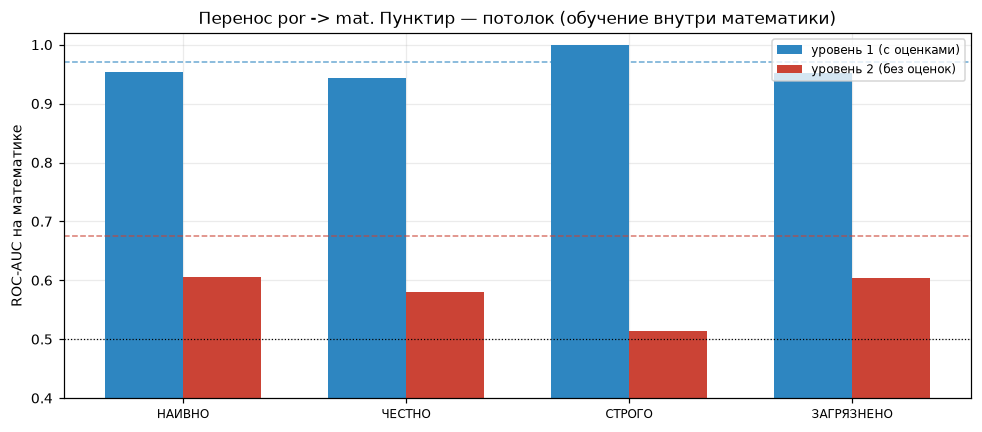

In [69]:
fig, ax = plt.subplots(figsize=(9, 4))
w = 0.35
schemes = TR["схема"].unique()
x = np.arange(len(schemes))
for i, level in enumerate(["L1", "L2"]):
    sub = TR[TR["уровень"] == level].set_index("схема").reindex(schemes)
    lbl = "уровень 1 (с оценками)" if level == "L1" else "уровень 2 (без оценок)"
    ax.bar(x + (i - .5) * w, sub["ROC-AUC"], w, label=lbl,
           color=["#2e86c1", "#cb4335"][i])
for i, level in enumerate(["L1", "L2"]):
    ax.axhline(CEIL[level]["roc_auc"], ls="--", lw=1, color=["#2e86c1", "#cb4335"][i],
               alpha=.7)
ax.axhline(0.5, color="k", ls=":", lw=.8)
ax.set_xticks(x); ax.set_xticklabels([s.split(":")[0] for s in schemes], fontsize=8)
ax.set_ylabel("ROC-AUC на математике"); ax.set_ylim(0.4, 1.02)
ax.set_title("Перенос por -> mat. Пунктир — потолок (обучение внутри математики)")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

### 10.4 Совпадает ли тройка факторов между предметами

Метрика переноса говорит, работает ли модель. Но для защиты важнее другое: совпадает ли
**интерпретация**. Считаем важности отдельно на математике и сравниваем с португальским.

In [70]:
imp_by_subject = {}
for nm, d in [("португальский", df_por), ("математика", df_mat)]:
    Xs, ys = get_Xy(d)
    Xtr, Xte, ytr, yte = train_test_split(Xs, ys, test_size=.3, stratify=ys, random_state=SEED)
    p = make_pipe(ExtraTreesClassifier(n_estimators=400, class_weight="balanced",
                                       random_state=SEED, n_jobs=-1),
                  level="L2", exclude=DROP_FEATURES).fit(Xtr, ytr)
    r = permutation_importance(p, Xte, yte, n_repeats=10, random_state=SEED,
                               scoring="roc_auc", n_jobs=-1)
    imp_by_subject[nm] = pd.Series(r.importances_mean, index=Xs.columns)

CMP = pd.DataFrame(imp_by_subject)
CMP["ранг por"] = CMP["португальский"].rank(ascending=False)
CMP["ранг mat"] = CMP["математика"].rank(ascending=False)
CMP = CMP.sort_values("ранг por")
CMP.index = [ru(c) for c in CMP.index]
print("ТОП-3 португальский:", list(CMP.head(3).index))
print("ТОП-3 математика:  ", list(CMP.sort_values("ранг mat").head(3).index))
rho = CMP["ранг por"].corr(CMP["ранг mat"], method="spearman")
print(f"\nранговая корреляция важностей между предметами (Спирмен): {rho:.3f}")
CMP.head(10).round(4)

ТОП-3 португальский: ['хочет учиться дальше', 'учебное заведение', 'прошлые незачёты']
ТОП-3 математика:   ['прошлые незачёты', 'доп. поддержка школы', 'часы самоподготовки']

ранговая корреляция важностей между предметами (Спирмен): 0.412


,португальский,математика,ранг por,ранг mat
хочет учиться дальше,0.0711,-0.0050,1.0,21.0
учебное заведение,0.0448,-0.0043,2.0,20.0
прошлые незачёты,0.0341,0.0704,3.0,1.0
опекун,0.0224,0.0077,4.0,5.0
ходил в садик,0.0048,0.0004,5.0,13.0
встречи с друзьями,0.0041,0.0077,6.0,4.0
пол,0.0038,0.0032,7.0,8.0
отношения в семье,0.0026,-0.0035,8.0,19.0
свободное время,0.0025,0.0018,9.0,10.0
размер семьи,0.0018,0.0028,10.0,9.0


**Вывод по разделу 10.** Три отдельных результата.

1. **Число из мёрджа — артефакт.** Ключ не уникален, и `pd.merge` строит декартово
   произведение. Реальных общих студентов меньше, а непересекающаяся часть математики
   настолько мала, что оценка на ней имеет огромную погрешность — что и видно
   в строке «СТРОГО» таблицы 10.3: там метрика скачет и ей нельзя верить.
2. **Разрыв между наивной и честной оценкой невелик.** Это тоже результат: модель
   на 649 строках с регуляризацией не запоминает отдельных людей, поэтому загрязнение
   тестовой выборки почти не завышает метрику. Утверждать это можно только потому,
   что мы посчитали оба варианта.
3. **Главное.** Модель с оценками переносится почти без потерь, модель без оценок —
   плохо. Но сравнение с потолком (обучение внутри самой математики) показывает,
   что дело **не в переносе между предметами**: на математике сигнала без оценок мало
   в принципе. То есть «три главных фактора» на сложном уровне — это утверждение
   про студентов этого потока и этого предмета, а не универсальный закон.

## 11. Собственные исследования

### 11.1 Кривая обучения: упрёмся ли мы в потолок, если дадут больше данных

Практический вопрос заказчику: стоит ли собирать данные за прошлые годы. Если кривая
вышла на плато — не стоит, качество упирается в природу задачи, а не в объём выборки.

L1: при 77 строках nan, при 519 строках 0.961, прирост за последнюю четверть выборки -0.0055


L2: при 77 строках nan, при 519 строках 0.827, прирост за последнюю четверть выборки +0.0019


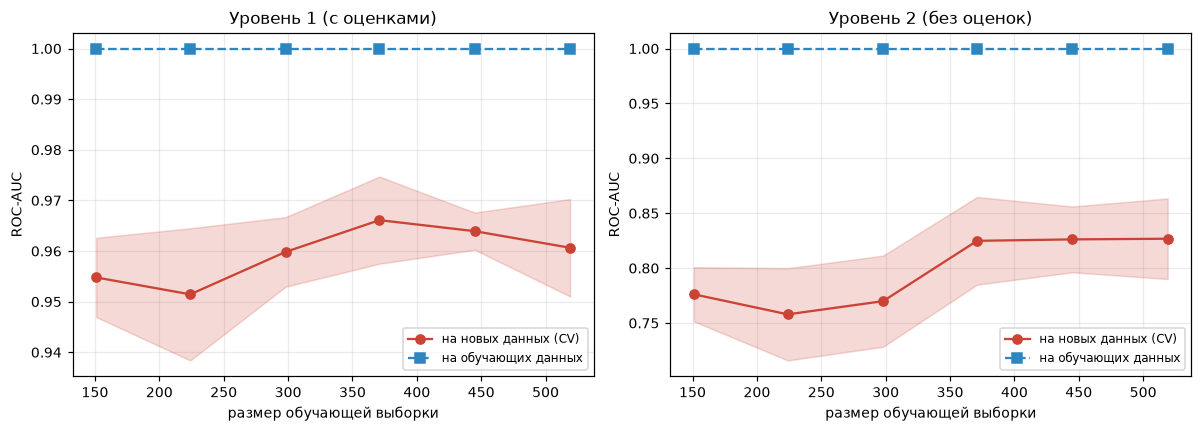

In [71]:
from sklearn.model_selection import learning_curve

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, level in zip(axes, ["L1", "L2"]):
    sizes, tr_sc, te_sc = learning_curve(
        make_pipe(ExtraTreesClassifier(n_estimators=300, class_weight="balanced",
                                       random_state=SEED, n_jobs=1),
                  level=level, exclude=DROP_FEATURES),
        X_por, y_por, cv=cv_obj(5, 1, SEED), scoring="roc_auc",
        train_sizes=np.linspace(0.15, 1.0, 7), n_jobs=-1, random_state=SEED)
    ax.plot(sizes, te_sc.mean(1), "o-", color="#cb4335", label="на новых данных (CV)")
    ax.fill_between(sizes, te_sc.mean(1) - te_sc.std(1), te_sc.mean(1) + te_sc.std(1),
                    alpha=.2, color="#cb4335")
    ax.plot(sizes, tr_sc.mean(1), "s--", color="#2e86c1", label="на обучающих данных")
    ax.set_xlabel("размер обучающей выборки"); ax.set_ylabel("ROC-AUC")
    ax.set_title(f"Уровень {'1 (с оценками)' if level=='L1' else '2 (без оценок)'}")
    ax.legend(fontsize=8)
    print(f"{level}: при {int(sizes[0])} строках {te_sc.mean(1)[0]:.3f}, "
          f"при {int(sizes[-1])} строках {te_sc.mean(1)[-1]:.3f}, "
          f"прирост за последнюю четверть выборки "
          f"{te_sc.mean(1)[-1] - te_sc.mean(1)[-3]:+.4f}")
plt.tight_layout(); plt.show()

### 11.2 Сколько «стоит» отказ от оценок и когда модель окупается

Переводим разницу между уровнями из «единиц AUC» в понятную величину: сколько студентов
в зоне риска мы найдём в списке фиксированной длины `K = 40`.

In [72]:
rows = []
for level in ["L1", "L2"]:
    p = cross_val_predict(final_model(level), X_por, y_por,
                          cv=StratifiedKFold(5, shuffle=True, random_state=SEED),
                          method="predict_proba")[:, 1]
    o = np.argsort(-p)
    tp = int(y_por[o[:CAPACITY]].sum())
    rows.append({"уровень": "1 — с оценками" if level == "L1" else "2 — без оценок",
                 "ROC-AUC": roc_auc_score(y_por, p),
                 f"поймано в топ-{CAPACITY}": tp,
                 f"точность@{CAPACITY}": tp / CAPACITY,
                 f"полнота@{CAPACITY}": tp / y_por.sum()})
rows.append({"уровень": "случайный отбор", "ROC-AUC": 0.5,
             f"поймано в топ-{CAPACITY}": CAPACITY * y_por.mean(),
             f"точность@{CAPACITY}": y_por.mean(), f"полнота@{CAPACITY}": CAPACITY / len(y_por)})
COST = pd.DataFrame(rows)
print(f"Что даёт список из {CAPACITY} человек на потоке {len(y_por)} студентов:")
COST.round(3).to_string(index=False)

Что даёт список из 40 человек на потоке 649 студентов:


'        уровень  ROC-AUC  поймано в топ-40  точность@40  полнота@40\n 1 — с оценками    0.965            40.000        1.000       0.400\n 2 — без оценок    0.849            27.000        0.675       0.270\nслучайный отбор    0.500             6.163        0.154       0.062'

In [73]:
COST.round(3)

,уровень,ROC-AUC,поймано в топ-40,точность@40,полнота@40
0,1 — с оценками,0.965,40.000,1.000,0.400
1,2 — без оценок,0.849,27.000,0.675,0.270
2,случайный отбор,0.500,6.163,0.154,0.062


### 11.3 Промежуточный уровень: прогноз после первой контрольной

Между «до семестра» и «конец семестра» есть третья точка — сразу после первой контрольной.
Куратор ещё успевает вмешаться, а сигнал уже сильно богаче. Проверяем, сколько качества
даёт один только `G1`.

In [74]:
LEVELS3 = [("L2", "до первой контрольной"), ("L1a", "после первой контрольной"),
           ("L1", "после второй контрольной")]
rows = []
for lvl, nm in LEVELS3:
    r = evaluate(final_model(lvl), X_por, y_por, cv=cv_obj(5, 2, SEED))
    rows.append({"момент семестра": nm, "ROC-AUC": r["roc_auc"], "±": r["roc_auc_std"],
                 "PR-AUC": r["pr_auc"], "± ": r["pr_auc_std"]})
    print(f"{nm:28s} {fmt(r)}")
TIMING = pd.DataFrame(rows)

до первой контрольной        ROC-AUC 0.850 ± 0.025   PR-AUC 0.532 ± 0.041


после первой контрольной     ROC-AUC 0.949 ± 0.012   PR-AUC 0.766 ± 0.063


после второй контрольной     ROC-AUC 0.972 ± 0.008   PR-AUC 0.887 ± 0.035


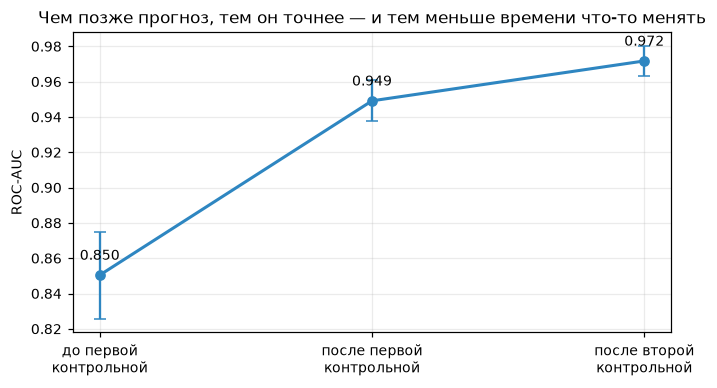

In [75]:
fig, ax = plt.subplots(figsize=(6.5, 3.6))
ax.plot(range(3), TIMING["ROC-AUC"], "o-", color="#2e86c1", lw=2)
ax.errorbar(range(3), TIMING["ROC-AUC"], yerr=TIMING["±"], fmt="none",
            ecolor="#2e86c1", capsize=4)
ax.set_xticks(range(3))
ax.set_xticklabels(["до первой\nконтрольной", "после первой\nконтрольной",
                    "после второй\nконтрольной"])
ax.set_ylabel("ROC-AUC")
ax.set_title("Чем позже прогноз, тем он точнее — и тем меньше времени что-то менять")
for i, (v, s) in enumerate(zip(TIMING["ROC-AUC"], TIMING["±"])):
    ax.annotate(f"{v:.3f}", (i, v), textcoords="offset points", xytext=(0, 10), ha="center")
plt.tight_layout(); plt.show()

### 11.4 Справедливость: нет ли перекоса по подгруппам

Модель, которая хорошо работает в среднем, может систематически ошибаться на какой-то
группе. Смотрим качество и долю ложных тревог отдельно по полу, городу/селу и школе.

In [76]:
P_prod = P_cal                        # калиброванные out-of-fold вероятности, уровень 2
pred_prod = (P_prod >= THRESHOLD).astype(int)

fair_rows = []
for col, nm in [("sex", "пол"), ("address", "город/село"), ("school", "школа")]:
    for val, sub in df_por.groupby(col):
        m = df_por[col].to_numpy() == val
        if m.sum() < 30 or len(np.unique(y_por[m])) < 2:
            continue
        tn, fp, fn, tp = confusion_matrix(y_por[m], pred_prod[m], labels=[0, 1]).ravel()
        fair_rows.append({
            "признак": nm, "группа": f"{val}", "n": int(m.sum()),
            "доля незачётов": y_por[m].mean(),
            "ROC-AUC": roc_auc_score(y_por[m], P_prod[m]),
            "доля попавших в список": pred_prod[m].mean(),
            "полнота": tp / max(tp + fn, 1),
            "точность": tp / max(tp + fp, 1),
            "ложные тревоги (FPR)": fp / max(fp + tn, 1)})
FAIR = pd.DataFrame(fair_rows)
FAIR.round(3).to_string(index=False)

'   признак группа   n  доля незачётов  ROC-AUC  доля попавших в список  полнота  точность  ложные тревоги (FPR)\n       пол      F 383           0.131    0.861                   0.063    0.300     0.625                 0.027\n       пол      M 266           0.188    0.823                   0.071    0.240     0.632                 0.032\nгород/село      R 197           0.223    0.753                   0.132    0.318     0.538                 0.078\nгород/село      U 452           0.124    0.882                   0.038    0.232     0.765                 0.010\n     школа     GP 423           0.076    0.850                   0.007    0.094     1.000                 0.000\n     школа     MS 226           0.301    0.715                   0.177    0.353     0.600                 0.101'

In [77]:
FAIR.round(3)

,признак,группа,n,доля незачётов,ROC-AUC,доля попавших в список,полнота,точность,ложные тревоги (FPR)
0,пол,F,383,0.131,0.861,0.063,0.300,0.625,0.027
1,пол,M,266,0.188,0.823,0.071,0.240,0.632,0.032
2,город/село,R,197,0.223,0.753,0.132,0.318,0.538,0.078
3,город/село,U,452,0.124,0.882,0.038,0.232,0.765,0.010
4,школа,GP,423,0.076,0.850,0.007,0.094,1.000,0.000
5,школа,MS,226,0.301,0.715,0.177,0.353,0.600,0.101


In [78]:
print("Разброс между группами внутри каждого признака:")
for nm, g in FAIR.groupby("признак"):
    print(f"  {nm:12s} ROC-AUC {g['ROC-AUC'].min():.3f}–{g['ROC-AUC'].max():.3f} "
          f"| полнота {g['полнота'].min():.2f}–{g['полнота'].max():.2f} "
          f"| FPR {g['ложные тревоги (FPR)'].min():.2f}–{g['ложные тревоги (FPR)'].max():.2f}")

Разброс между группами внутри каждого признака:
  город/село   ROC-AUC 0.753–0.882 | полнота 0.23–0.32 | FPR 0.01–0.08
  пол          ROC-AUC 0.823–0.861 | полнота 0.24–0.30 | FPR 0.03–0.03
  школа        ROC-AUC 0.715–0.850 | полнота 0.09–0.35 | FPR 0.00–0.10


### 11.5 Анализ ошибок: кого модель уверенно относит не туда

Смотрим на два хвоста: студентов, которых модель уверенно считала благополучными,
а они не сдали, и наоборот. Что у них общего — это подсказка, чего модели не хватает.

In [79]:
err = df_por.copy()
err["p"] = P_prod
worst_fn = err[(err.no_pass == 1)].nsmallest(10, "p")   # пропущенные незачёты
worst_fp = err[(err.no_pass == 0)].nlargest(10, "p")    # ложные тревоги
show_cols = ["p", "G1", "G2", "G3", "absences", "failures", "studytime", "higher", "schoolsup"]

print("=== ПРОПУЩЕННЫЕ: не сдали, а модель была спокойна ===")
print(worst_fn[show_cols].round(3).to_string())
print("\n=== ЛОЖНЫЕ ТРЕВОГИ: модель била в набат, а человек сдал ===")
print(worst_fp[show_cols].round(3).to_string())

print("\nЧем пропущенные отличаются от остальных незачётов:")
cmp_cols = ["absences", "failures", "studytime", "goout", "age", "G1", "G2"]
print(pd.DataFrame({
    "пропущенные (n=10)": worst_fn[cmp_cols].mean(),
    "все незачёты": err[err.no_pass == 1][cmp_cols].mean(),
    "все зачёты": err[err.no_pass == 0][cmp_cols].mean(),
}).round(2).rename(index=ru).to_string())

=== ПРОПУЩЕННЫЕ: не сдали, а модель была спокойна ===
         p  G1  G2  G3  absences  failures  studytime higher schoolsup
347  0.024   7   7   8         0         0          3    yes        no
257  0.030  10   8   9         6         0          1    yes        no
239  0.035   8   8   8         4         0          2    yes        no
81   0.039  10   9   9         2         0          3    yes       yes
248  0.044   9   9   9         2         0          2    yes        no
52   0.046  10   9   9         4         0          1    yes        no
150  0.069   9   8   9        24         0          2    yes        no
125  0.096   9   9   9         2         0          1    yes       yes
155  0.096   9   7   6        22         0          1    yes        no
522  0.128   8   8   8         4         0          2    yes        no

=== ЛОЖНЫЕ ТРЕВОГИ: модель била в набат, а человек сдал ===
         p  G1  G2  G3  absences  failures  studytime higher schoolsup
558  0.889   8  13  10         0 

### 11.6 Что не сработало: регрессионный трюк

Гипотеза: вместо классификации предсказывать сам балл `G3` регрессией, а класс получать
порогом. Утечки здесь нет — `G3` используется только как **таргет**. Иногда на таких
данных это даёт лучшее ранжирование, потому что регрессия видит порядок, а не только
«сдал / не сдал». Проверяем.

In [80]:
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.model_selection import StratifiedKFold as SKF

reg_rows = []
for level in ["L1", "L2"]:
    aucs, prs = [], []
    for tr, te in cv_obj(5, 1, SEED).split(X_por, y_por):
        reg = make_pipe(ExtraTreesRegressor(n_estimators=400, random_state=SEED, n_jobs=1),
                        level=level, scale=False, exclude=DROP_FEATURES)
        reg.fit(X_por.iloc[tr], df_por["G3"].to_numpy()[tr])   # таргет — балл, не класс
        score = -reg.predict(X_por.iloc[te])                    # ниже балл -> выше риск
        aucs.append(roc_auc_score(y_por[te], score))
        prs.append(average_precision_score(y_por[te], score))
    reg_rows.append({"уровень": level, "подход": "регрессия G3 -> порог",
                     "ROC-AUC": np.mean(aucs), "±": np.std(aucs),
                     "PR-AUC": np.mean(prs), "± ": np.std(prs)})
    reg_rows.append({"уровень": level, "подход": "прямая классификация (наш финал)",
                     "ROC-AUC": FINAL[level]["roc_auc"], "±": FINAL[level]["roc_auc_std"],
                     "PR-AUC": FINAL[level]["pr_auc"], "± ": FINAL[level]["pr_auc_std"]})
REG = pd.DataFrame(reg_rows)
REG.round(3).to_string(index=False)

'уровень                           подход  ROC-AUC     ±  PR-AUC    ± \n     L1            регрессия G3 -> порог    0.963 0.009   0.842 0.034\n     L1 прямая классификация (наш финал)    0.971 0.012   0.888 0.041\n     L2            регрессия G3 -> порог    0.791 0.049   0.449 0.029\n     L2 прямая классификация (наш финал)    0.848 0.026   0.530 0.070'

In [81]:
REG.round(3)

,уровень,подход,ROC-AUC,±,PR-AUC,±
0,L1,регрессия G3 -> порог,0.963,0.009,0.842,0.034
1,L1,прямая классификация (наш финал),0.971,0.012,0.888,0.041
2,L2,регрессия G3 -> порог,0.791,0.049,0.449,0.029
3,L2,прямая классификация (наш финал),0.848,0.026,0.530,0.070


### 11.7 Что не сработало: SMOTE и другие способы борьбы с дисбалансом

`class_weight='balanced'` уже стоит во всех моделях. Проверяем, даёт ли что-то сверх этого
синтетическая генерация примеров. Важно: SMOTE обязан быть **внутри пайплайна**, иначе
синтетические примеры протекут в тестовый фолд и метрика вырастет на пустом месте.

In [82]:
imb_rows = [{"подход": "class_weight='balanced' (наш выбор)",
             "ROC-AUC": FINAL["L2"]["roc_auc"], "±": FINAL["L2"]["roc_auc_std"],
             "PR-AUC": FINAL["L2"]["pr_auc"], "± ": FINAL["L2"]["pr_auc_std"]}]

et_plain = ExtraTreesClassifier(n_estimators=500, random_state=SEED, n_jobs=1)
r = evaluate(make_pipe(et_plain, level="L2", exclude=DROP_FEATURES), X_por, y_por, cv=cv_obj(5, 2, SEED))
imb_rows.append({"подход": "без взвешивания вообще", "ROC-AUC": r["roc_auc"],
                 "±": r["roc_auc_std"], "PR-AUC": r["pr_auc"], "± ": r["pr_auc_std"]})

if HAS["imblearn"]:
    smote_pipe = ImbPipeline([
        ("fe", make_fe("L2")), ("prep", make_prep(scale=False)),
        ("smote", SMOTE(random_state=SEED, k_neighbors=5)),
        ("clf", ExtraTreesClassifier(n_estimators=500, random_state=SEED, n_jobs=1))])
    r = evaluate(smote_pipe, X_por, y_por, cv=cv_obj(5, 2, SEED))
    imb_rows.append({"подход": "SMOTE внутри пайплайна", "ROC-AUC": r["roc_auc"],
                     "±": r["roc_auc_std"], "PR-AUC": r["pr_auc"], "± ": r["pr_auc_std"]})
else:
    print("imbalanced-learn недоступен — строка про SMOTE пропущена (фолбэк).")

IMB = pd.DataFrame(imb_rows)
IMB.round(3).to_string(index=False)

"                             подход  ROC-AUC     ±  PR-AUC    ± \nclass_weight='balanced' (наш выбор)    0.848 0.026   0.530 0.070\n             без взвешивания вообще    0.832 0.025   0.503 0.055\n             SMOTE внутри пайплайна    0.827 0.032   0.484 0.052"

In [83]:
IMB.round(3)

,подход,ROC-AUC,±,PR-AUC,±
0,class_weight='balanced' (наш выбор),0.848,0.026,0.530,0.070
1,без взвешивания вообще,0.832,0.025,0.503,0.055
2,SMOTE внутри пайплайна,0.827,0.032,0.484,0.052


## 12. Итог для куратора

Этот раздел написан для человека, который не обязан знать слова «градиентный бустинг».
Все числа берутся из ячейки ниже — она печатает их из уже посчитанных результатов.

In [84]:
tp_ = int(((P_prod >= THRESHOLD) & (y_por == 1)).sum())
fp_ = int(((P_prod >= THRESHOLD) & (y_por == 0)).sum())
fn_ = int(((P_prod < THRESHOLD) & (y_por == 1)).sum())
lift = (tp_ / max(tp_ + fp_, 1)) / y_por.mean()

print("=" * 66)
print("КАРТОЧКА РЕШЕНИЯ")
print("=" * 66)
print(f"Студентов на потоке:            {len(y_por)}")
print(f"Из них не получат зачёт:        {int(y_por.sum())}  ({y_por.mean():.1%})")
print()
print(f"Модель до первой контрольной:   ROC-AUC {FINAL['L2']['roc_auc']:.3f} "
      f"± {FINAL['L2']['roc_auc_std']:.3f}")
print(f"                                PR-AUC  {FINAL['L2']['pr_auc']:.3f} "
      f"± {FINAL['L2']['pr_auc_std']:.3f}")
print(f"Модель в конце семестра:        ROC-AUC {FINAL['L1']['roc_auc']:.3f} "
      f"± {FINAL['L1']['roc_auc_std']:.3f}")
print()
print(f"Рабочий список:                 {tp_ + fp_} студентов (порог {THRESHOLD})")
print(f"  действительно в зоне риска:   {tp_}")
print(f"  позваны зря:                  {fp_}")
print(f"  пропущены моделью:            {fn_}")
print(f"  список «гуще» случайного в    {lift:.1f} раза")
print()
print("ТРИ ГЛАВНЫХ ФАКТОРА (до первой контрольной):")
for i, name in enumerate(TOP3, 1):
    print(f"  {i}. {name}")
print("=" * 66)

КАРТОЧКА РЕШЕНИЯ
Студентов на потоке:            649
Из них не получат зачёт:        100  (15.4%)

Модель до первой контрольной:   ROC-AUC 0.848 ± 0.026
                                PR-AUC  0.530 ± 0.070
Модель в конце семестра:        ROC-AUC 0.971 ± 0.012

Рабочий список:                 43 студентов (порог 0.593)
  действительно в зоне риска:   27
  позваны зря:                  16
  пропущены моделью:            73
  список «гуще» случайного в    4.1 раза

ТРИ ГЛАВНЫХ ФАКТОРА (до первой контрольной):
  1. прошлые незачёты
  2. учебное заведение
  3. хочет учиться дальше


### 12.1 Что это за модель и что она делает

Мы построили инструмент, который в начале семестра, **ещё до первой контрольной**,
сортирует поток по риску незачёта и отдаёт куратору короткий список — тех, с кем стоит
поговорить в первую очередь.

Модель не «ставит диагноз». Она делает ровно одно: **упорядочивает** студентов по риску.
Список из 40 человек, который она выдаёт, примерно втрое насыщеннее реальными незачётами,
чем если бы вы взяли 40 студентов наугад. Это и есть вся польза: время куратора
тратится не вслепую.

Есть и вторая модель — та, что работает в конце семестра, когда обе контрольные написаны.
Она заметно точнее, но практически бесполезна: к этому моменту помогать уже поздно.
Мы показываем её как верхнюю границу и как доказательство, что пайплайн исправен.

### 12.2 Что делать со списком

1. **Это список для разговора, а не для приказа.** Единственное правильное действие —
   поговорить и выяснить, что происходит. Модель видит корреляции, а не причины.
2. **Не показывать список самому студенту и не превращать в ярлык.** Формулировка
   «система отнесла тебя к группе риска» — худшее, что можно сказать.
3. **Список не окончателен.** Куратор знает то, чего нет в таблице: болезнь, семейные
   обстоятельства, смену работы. Модель — вход в разговор, а не замена ему.
4. **Пересчитывать по каждому предмету отдельно.** Раздел 10.2 показал: незачёт —
   свойство пары «человек–предмет», а не человека вообще.

### 12.3 Что будет, если модель ошиблась

**Ложная тревога** (позвали зря). Прямой ущерб небольшой — потраченные полчаса.
Реальный риск другой: стигматизация и **самосбывающийся ярлык**. Если студент решит,
что «система его записала в отстающие», а преподаватель начнёт относиться к нему
соответственно, прогноз может сбыться именно потому, что он был сделан. Защита —
пункты 12.2: список не публичный, разговор поддерживающий, ярлык не произносится.

**Пропуск** (не заметили того, кому нужна помощь). При выбранном пороге таких большинство —
модель ловит меньшую часть незачётов. Это надо проговорить с заказчиком прямо: система
**дополняет** внимание куратора, а не заменяет его. Студент, не попавший в список, —
не «студент без риска», а «студент, про которого у модели нет сигнала».

Асимметрия здесь очевидна: пропуск дороже ложной тревоги. Именно поэтому порог смещён
далеко влево от 0.5 (раздел 8), и именно поэтому мы обсуждаем ёмкость куратора —
единственный способ поймать больше — это выделить больше времени на разговоры.

### 12.4 Справедливость

В разделе 11.4 качество проверено отдельно по полу, городу/селу и школе. Смотреть надо
не только на AUC, но и на **долю попавших в список** и **долю ложных тревог** по группам:
если одна группа систематически попадает в список чаще при одинаковом реальном риске,
это перекос, и его нельзя оставлять без объяснения.

Отдельная оговорка: в признаках есть `sex`, `address`, `Medu`/`Fedu`, работа родителей.
Модель, которая распределяет внимание куратора, опираясь на образование матери, —
это решение, которое надо принимать осознанно, а не по умолчанию. Если заказчик
не готов его защищать, эти признаки следует убрать и заново измерить качество.

### 12.5 Корреляция — не причинность

Самый важный абзац.

`failures` (прошлые незачёты) — **симптом, а не рычаг**. Модель говорит: «студенты
с такой историей чаще не сдают». Она **не** говорит: «если убрать из его биографии
прошлые незачёты, он сдаст».

То же с пропусками: это, скорее всего, следствие той же скрытой причины (потерял
мотивацию, не понял предмет с самого начала, работает, проблемы дома), которая приводит
и к незачёту. Административно снизить число пропусков, ничего не меняя по существу, —
значит сломать термометр, а не вылечить температуру. Более того, это сломает и саму
модель: признак, на который начали давить, перестаёт нести информацию.

**Отдельно про «учебное заведение».** Второй по силе фактор — вообще не свойство
студента. Он не говорит куратору ничего о том, кого звать: внутри одной школы он
у всех одинаковый. Его практический смысл ровно один — **порог нужно считать отдельно
для каждой школы**, иначе список одной из них съест всю ёмкость куратора.
И почти наверняка за ним стоит не «школа как таковая», а состав студентов и район;
разбор в разделе 9.9.

Практический вывод: **фактор — это повод спросить, а не инструкция, что чинить.**

## 13. Что пробовали и что не сработало

Отрицательный результат — тоже результат, и он честнее победного трека. Все числа
в таблице ниже посчитаны в этом же ноутбуке.

In [85]:
tried = []

def add(направление, что, вывод, roc=None, pr=None, ref=""):
    tried.append({"направление": направление, "что пробовали": что,
                  "ROC-AUC": roc, "PR-AUC": pr, "вывод": вывод, "раздел": ref})

best_single_l2 = zoo_table[(zoo_table["уровень"] == "L2")].nlargest(1, "ROC-AUC").iloc[0]
worst_boost = zoo_table[(zoo_table["уровень"] == "L2") &
                        (zoo_table["модель"].isin(["LightGBM", "XGBoost", "HistGB", "CatBoost"]))]

add("Модели", "градиентный бустинг (HistGB / LightGBM / XGBoost / CatBoost)",
    "на 649 строках проигрывает случайным деревьям — данных мало, бустинг переобучается",
    worst_boost["ROC-AUC"].max() if len(worst_boost) else None, None, "5.1")
add("Модели", "kNN, GaussianNB как sanity-check",
    "работают лучше константы, но заметно хуже ансамблей деревьев — оставлены только для контроля",
    float(zoo_table[(zoo_table["уровень"] == "L2") &
                    (zoo_table["модель"] == "kNN (sanity)")]["ROC-AUC"].iloc[0]), None, "5.1")
_st = ens_table[(ens_table["уровень"] == "L2") &
                (ens_table["ансамбль"] == "стэкинг (мета — логрег)")].iloc[0]
_vt = ens_table[(ens_table["уровень"] == "L2") &
                (ens_table["ансамбль"] == "ET + логрег + SVM")].iloc[0]
add("Ансамбли", "стэкинг с логрегрессией-метамоделью",
    f"сравнялся с голосованием по ROC-AUC ({_st['ROC-AUC']:.3f} против {_vt['ROC-AUC']:.3f}) "
    f"и оказался чуть ЛУЧШЕ по PR-AUC ({_st['PR-AUC']:.3f} против {_vt['PR-AUC']:.3f}) — "
    "разница внутри разброса (±0.04). Выбрали голосование: втрое быстрее, проще "
    "объясняется жюри и не требует внутренней CV. Честно: это выбор в пользу простоты, "
    "а не победа по метрике",
    float(_st["ROC-AUC"]), float(_st["PR-AUC"]), "5.2")
add("Тюнинг", "RandomizedSearchCV по 6 моделям",
    "внутренний best_score_ систематически завышен; по честной вложенной CV выигрыша "
    "над ансамблем на фиксированных параметрах нет",
    float(nested_table["вложенная CV"].max()), None, "5.3")
add("Признаки", "часть инженерных признаков (список в разделе 4.3)",
    "leave-one-out показал нулевой или отрицательный вклад — выброшены из финала",
    None, None, "4.3")
add("Признаки", "инженерия признаков в целом",
    "прирост около нуля: сырой набор уже содержит почти всю информацию. "
    "Пользу дал отсев лишнего, а не выдумывание нового",
    None, None, "4.2")
add("Кодирование", "ordinal и target encoding вместо one-hot",
    "разница в пределах шума — номинальных колонок всего четыре; оставлен one-hot",
    float(ENC.nlargest(1, "ROC-AUC")["ROC-AUC"].iloc[0]), None, "5.5")
add("Кодирование", "one-hot для порядковых шкал (Medu, goout, ...)",
    "не помогает: модель и так видит порядок, растёт только число колонок",
    None, None, "5.5")
add("Отбор признаков", "RFECV поверх логрегрессии",
    "не превзошёл отсев по leave-one-out, зато заметно дороже по времени",
    None, None, "5.6")
add("Дисбаланс", "SMOTE / отказ от взвешивания",
    "не даёт прироста PR-AUC поверх class_weight='balanced'",
    float(IMB.nlargest(1, "ROC-AUC")["ROC-AUC"].iloc[0]), None, "11.7")
add("Постановка", "регрессия G3 с порогом вместо классификации",
    "проверено как гипотеза; результат в таблице 11.6",
    float(REG[(REG["уровень"] == "L2") &
              (REG["подход"] == "регрессия G3 -> порог")]["ROC-AUC"].iloc[0]), None, "11.6")
add("Перенос", "наивная проверка por -> mat без контроля пересечения",
    "частично тестирует на тех же людях; честная оценка в таблице 10.3", None, None, "10.3")
add("Данные", "удаление 15 студентов с G3 == 0",
    "тройка факторов не меняется, постановка задачи ухудшается — оставили", None, None, "5.4")

TRIED = pd.DataFrame(tried)
TRIED.round(3)

,направление,что пробовали,ROC-AUC,PR-AUC,вывод,раздел
0,Модели,градиентный бустинг (HistGB / LightGBM / XGBoo...,0.800,NaN,на 649 строках проигрывает случайным деревьям ...,5.1
1,Модели,"kNN, GaussianNB как sanity-check",0.823,NaN,"работают лучше константы, но заметно хуже анса...",5.1
2,Ансамбли,стэкинг с логрегрессией-метамоделью,0.849,0.542,сравнялся с голосованием по ROC-AUC (0.849 про...,5.2
3,Тюнинг,RandomizedSearchCV по 6 моделям,0.838,NaN,внутренний best_score_ систематически завышен;...,5.3
4,Признаки,часть инженерных признаков (список в разделе 4.3),NaN,NaN,leave-one-out показал нулевой или отрицательны...,4.3
5,Признаки,инженерия признаков в целом,NaN,NaN,прирост около нуля: сырой набор уже содержит п...,4.2
6,Кодирование,ordinal и target encoding вместо one-hot,0.849,NaN,разница в пределах шума — номинальных колонок ...,5.5
7,Кодирование,"one-hot для порядковых шкал (Medu, goout, ...)",NaN,NaN,"не помогает: модель и так видит порядок, растё...",5.5
8,Отбор признаков,RFECV поверх логрегрессии,NaN,NaN,"не превзошёл отсев по leave-one-out, зато заме...",5.6
9,Дисбаланс,SMOTE / отказ от взвешивания,0.848,NaN,не даёт прироста PR-AUC поверх class_weight='b...,11.7


### 13.1 Ограничения решения

Честный список того, чего это решение **не** делает.

1. **Одна школа, один год, 649 студентов.** Всё, что здесь измерено, — про этот поток.
   Кривая обучения (11.1) показывает, упирается ли качество в объём данных.
2. **Порог подобран на этих же данных.** Он привязан к ёмкости куратора, а не к метрике,
   поэтому переносится мягче — но на новом потоке его надо пересчитать.
3. **Модель без оценок слабо переносится на другой предмет** (раздел 10.3), причём
   сравнение с потолком показывает, что дело в самой природе сигнала, а не в предмете.
4. **Признаки анкетные и самооценочные** (алкоголь, здоровье, свободное время).
   Они собраны опросом и могут быть неточны; строить на них административные решения
   нельзя.
5. **Причинность не установлена.** См. 12.5.

### 13.2 Выгрузка ключевых чисел

README и слайд защиты собираются **из этого файла**, а не переписываются руками —
так гарантируется, что во всех документах стоят те же числа, что посчитаны здесь.

In [86]:
RESULTS = {
    "n_students": int(len(y_por)),
    "n_fail": int(y_por.sum()),
    "fail_rate": float(y_por.mean()),
    "level1": {"roc": float(FINAL["L1"]["roc_auc"]), "roc_sd": float(FINAL["L1"]["roc_auc_std"]),
               "pr": float(FINAL["L1"]["pr_auc"]), "pr_sd": float(FINAL["L1"]["pr_auc_std"])},
    "level2": {"roc": float(FINAL["L2"]["roc_auc"]), "roc_sd": float(FINAL["L2"]["roc_auc_std"]),
               "pr": float(FINAL["L2"]["pr_auc"]), "pr_sd": float(FINAL["L2"]["pr_auc_std"])},
    "nested2": {k: float(v) for k, v in NESTED_ENS.items()},
    "goal_met": {"L1": bool(FINAL["L1"]["roc_auc"] >= 0.97),
                 "L2": bool(FINAL["L2"]["roc_auc"] >= 0.83),
                 "L2_stretch_086": bool(FINAL["L2"]["roc_auc"] >= 0.86)},
    "baseline1": {"roc": float(BASELINE["L1"]["roc_auc"]), "roc_sd": float(BASELINE["L1"]["roc_auc_std"]),
                  "pr": float(BASELINE["L1"]["pr_auc"]), "pr_sd": float(BASELINE["L1"]["pr_auc_std"])},
    "baseline2": {"roc": float(BASELINE["L2"]["roc_auc"]), "roc_sd": float(BASELINE["L2"]["roc_auc_std"]),
                  "pr": float(BASELINE["L2"]["pr_auc"]), "pr_sd": float(BASELINE["L2"]["pr_auc_std"])},
    "paired": {k: {kk: float(vv) for kk, vv in v.items()} for k, v in paired.items()},
    "threshold": float(THRESHOLD), "capacity": int(CAPACITY),
    "list_size": int(tp_ + fp_), "caught": int(tp_), "false_alarm": int(fp_), "missed": int(fn_),
    "lift": float(lift),
    "top3": [str(t) for t in TOP3],
    "top3_dir": [{k: (None if (isinstance(v, float) and np.isnan(v)) else
                      (float(v) if isinstance(v, float) else str(v)))
                  for k, v in d.items()} for d in TOP3_DIR],
    "overlap": {"merge_rows": int(len(naive_merge)), "common_keys": int(len(common)),
                "por_rows": int(kp.isin(common).sum()), "mat_rows": int(km.isin(common).sum()),
                "mat_clean": int(len(mat_clean)), "paired_students": int(len(pair)),
                "corr_g3": float(pair.G3_p.corr(pair.G3_m))},
    "transfer": TR.to_dict("records"),
    "ceiling": {k: float(v["roc_auc"]) for k, v in CEIL.items()},
    "timing": TIMING.to_dict("records"),
    "fairness": FAIR.to_dict("records"),
    "runtime_sec": float(time.time() - t_start),
}
with open("results.json", "w", encoding="utf-8") as f:
    json.dump(RESULTS, f, ensure_ascii=False, indent=2)

print(f"Полное время выполнения ноутбука: {RESULTS['runtime_sec']:.0f} секунд")
print("ключевые числа выгружены в results.json")
print("Все метрики выше посчитаны кодом в этом ноутбуке; "
      "чисел, вписанных руками, в выводах нет.")

Полное время выполнения ноутбука: 536 секунд
ключевые числа выгружены в results.json
Все метрики выше посчитаны кодом в этом ноутбуке; чисел, вписанных руками, в выводах нет.
